# Severity: Gamma-benchmark for kostnad per registrert egen-skade

## 0. Formål, omfang og låste beslutninger

Målet er en transparent Gamma-benchmark for **registrert skadekostnad per
registrert skade**, og å avgjøre om et lite, forhåndslåst sett av avgrensede
endringer forbedrer en faglig og EDA-forankret baseline.

Styringsdokumentet er [`plans/Severity_plan.md`](plans/Severity_plan.md).
Frekvensfasen ligger i
[`glm_pricing_models.ipynb`](glm_pricing_models.ipynb) og er låst
(`F5_minus-municipality-performance`). Denne notebooken endrer ikke
frekvensmodellen.

**Dette er et låst løp, ikke et søk.** Kandidatrommet, foldene, scoren og
akseptgrensene er bestemt før første modell ble fittet. Et resultat kan ikke
begrunne en ny feature, en ny kategorigrense, en ny splinegrad eller en ny
terskel. Hensikten er å kunne rapportere en ærlig utviklingsscore i stedet for
en score som er optimert frem gjennom mange usynlige valg.

### Brukerbeslutninger som ligger fast

| Beslutning | Innhold |
|---|---|
| CV | Vanlig femfolds gruppe-CV på `insured_id`. Ingen indre CV, ingen ekstra holdout |
| Kandidatrom | Baselinen S0 og de tretten utfordrerne under er låst |
| Seter | Bare inndelingen `<5`, `=5`, `>5` |
| Enkelhet | Enklere modeller foretrekkes ved tilnærmet like resultater |
| Storskader | Undersøkes diagnostisk. **Ingen** kapping og **ingen** halemodell i dette løpet |
| Fordeling | Gamma. Inverse Gaussian er eneste mulige utfordrer, og krever egen, uttrykkelig godkjenning før den i det hele tatt implementeres |
| Testår | 2024 røres ikke. Teknisk årssplitt av kildefilen er tillatt; all videre behandling av 2024 er det ikke |

### Hva tallgrensene i notebooken er

1-SE-regelen og 0,5 %-grensen er **konservative beslutningsheuristikker**, ikke
signifikanstester. De brukes flere ganger på de samme valideringsobservasjonene
(enkeltkvalifisering, geografisammenligning, blokkvalg, kombinasjonskontroll,
finalistvalg). Beslutningene er derfor avhengige, de gir ingen kontrollert
samlet feilrate, og de fjerner ikke seleksjonsoptimismen. Det låste
kandidatbudsjettet begrenser søket, men opphever ikke dette forbeholdet.

### Beslutningsregister

Alle valg som påvirker resultatet får en ID (S-xx) og er samlet i seksjon 7.

In [1]:
import re
from functools import partial

import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display
from sklearn.metrics import mean_tweedie_deviance

from src.glm_core import (
    fit_glm,
    glm_spec,
    prepare_design_frame,
    prepare_fold_frames,
)
from src.model_data import assert_development_years, build_development_frames
from src_severity import (
    severity_bootstrap,
    severity_calibration,
    severity_descriptives,
    severity_influence,
    severity_time,
)
from src_severity.selection_tests import run_all
from src_severity.severity_cv import (
    build_fold_deviance_table,
    build_score_table,
    compare_pair,
    near_tie_choice,
    qualify_against,
    run_candidates,
)
from src_severity.severity_data import (
    build_severity_inputs,
    summarize_severity_selection,
)
from src_severity.severity_design_checks import (
    check_candidate_fold_design,
    summarize_candidate_design,
)
from src_severity.severity_folds import (
    build_fold_table,
    build_group_folds,
    make_full_population_hook,
)
from src_severity.severity_selection import (
    apply_geography_rule,
    build_selection_table,
    choose_near_tie,
    qualifies,
)

pd.set_option("display.max_columns", 60)

## 1. Datagrunnlag

### 1.1 Sikker utviklingsdataflyt (S-01)

Den tidligere innleseren renset **alle** år før testrammen ble fjernet. For
severity-fasen er flyten lagt om i `src/model_data.py`:

1. Kildefilen leses i biter, og hver bit avgrenses til 2022–2023 **før** noe
   annet skjer. 2024 materialiseres aldri som en ramme, renses aldri og
   transformeres aldri.
2. Hele utviklingspopulasjonen renses **før** produktavgrensning (rensekoden
   forventer en bestemt korreksjonsrad fra 2022).
3. Avgrensning, merke-pooling og transparente prediktorer er uendret fra
   frekvensfasen: `COMP_E`/`COMP_N`, positiv egen-skadepremie, positiv
   eksponering. Kansellerte poliser beholdes.
4. `assert_development_years` er en inngangskontroll som stopper kjøringen
   hvis et annet år enn utviklingsårene når en analysefunksjon.

Radidentitet og rekkefølge er bevart, slik at frekvens- og severity-foldene
kan kobles entydig senere. Kontrolltallene under er de samme som i
frekvensnotebooken, og verifiserer at omleggingen ikke endret populasjonen.

In [2]:
frames = build_development_frames()
development = frames["development"]
assert_development_years(development)  # stopper umiddelbart hvis 2024 skulle nådd hit

assert len(development) == 55_246
assert round(development["total_exposure"].sum(), 2) == 37_126.01
assert development["property_claims"].sum() == 9_989

display(frames["cleaning_log"])
display(
    pd.DataFrame(
        {
            "kontrollpunkt": ["poliseår", "sum eksponering", "registrerte skader"],
            "verdi": [
                len(development),
                round(development["total_exposure"].sum(), 2),
                int(development["property_claims"].sum()),
            ],
        }
    )
)

,step,affected_rows,result
0,"Kontroll av skjema, kategorikoder og unik poli...",0,Bestått
1,Fjerning av omkringliggende mellomrom i tekstfelt,0,Standardisert
2,Ikke-positiv power_to_weight_ratio satt til ma...,1,Standardisert
3,Manglende total- og ansvarseksponering satt ti...,1,Korrigert
4,Rader slettet eller imputert,0,Ingen


,kontrollpunkt,verdi
0,poliseår,55246.00
1,sum eksponering,37126.01
2,registrerte skader,9989.00


### 1.2 Respons, vekt og severity-utvalg (S-02)

Responsen er gjennomsnittlig skadekostnad per registrert skade i poliseåret:

$$
\bar X_i \;=\; \frac{S_i}{N_i},
\qquad
\bar X_i \sim \operatorname{Gamma}(\mu_i,\ \phi/N_i),
\qquad
\log \mu_i \;=\; x_i^{\top}\beta ,
$$

der $S_i$ er `property_incurred` og $N_i$ er `property_claims`. Modellen
estimeres med `var_weights = property_claims`, uten eksponeringsvekt og uten
eksponeringsoffset — severity er betinget på at en skade er registrert, så
eksponeringen er allerede «brukt opp» av frekvensmodellen.

**Utvalget** er poliseår med `property_claims > 0` og samlet
`property_incurred > 0.01`. De utelatte årene har numerisk tilnærmet null
kostnad; de inngår fortsatt i frekvens og i senere ren premie.

**Hva vekten gjør, og hva den forutsetter.** Skadeantallsvekten retter
modellen mot kostnad per registrert skade i aggregatet: et poliseår med fire
skader teller fire ganger så mye som ett med én skade. Det følger av at
gjennomsnittet av $N$ uavhengige Gamma-skader har varians $\mu^2/N$.
Observasjonene er imidlertid fortsatt **poliseår**, ikke rekonstruerte
enkeltskader. Arbeidsantakelsen om varians proporsjonal med $\mu^2/N$ kan
svikte hvis skadene innen samme poliseår er avhengige, og hvordan skadene
telles er ikke dokumentert i datakilden (åpent punkt B-03 fra fase 1).
Dette er en modelleringsantakelse vi bærer videre, ikke et verifisert faktum.

In [3]:
severity_inputs = build_severity_inputs(development)
model_frame = severity_inputs["model_frame"]
severity_frame = severity_inputs["severity_frame"]

# Seter som kategori (S-06): bare inndelingen <5 / =5 / >5, ingen andre grenser.
# Deterministisk transformasjon uten respons, så den kan gjøres én gang her.
for frame in (model_frame, severity_frame):
    frame["seat_category"] = np.select(
        [frame["seats"].lt(5), frame["seats"].eq(5)], ["<5", "=5"], default=">5"
    )

# Kategorinivåene låses fra utviklingsdata før første fit. De tre små
# kandidatene har forhåndsbestemte referanser fra frekvensarbeidet; merkets
# referanse låses til nivået med størst utviklingseksponering.
EXPECTED_CATEGORY_LEVELS = {
    "fuel_type": ("D", "G", "MISSING"),
    "business_type": ("NB", "P"),
    "payment_frequency": ("A", "Q", "S"),
    "vehicle_brand_pooled": (*frames["retained_brands"], "OTHER"),
}
LOCKED_CATEGORY_REFERENCES = {
    "fuel_type": "D",
    "business_type": "NB",
    "payment_frequency": "A",
    "vehicle_brand_pooled": development.groupby(
        "vehicle_brand_pooled", observed=True
    )["total_exposure"].sum().idxmax(),
}
for column, expected_levels in EXPECTED_CATEGORY_LEVELS.items():
    observed_levels = tuple(
        sorted(development[column].astype("string").fillna("MISSING").unique())
    )
    assert observed_levels == tuple(sorted(expected_levels)), (column, observed_levels)
for column, reference in LOCKED_CATEGORY_REFERENCES.items():
    assert reference in EXPECTED_CATEGORY_LEVELS[column], (column, reference)

category_lock_table = pd.DataFrame(
    {
        "variabel": list(EXPECTED_CATEGORY_LEVELS),
        "låste_nivåer": [", ".join(map(str, levels)) for levels in EXPECTED_CATEGORY_LEVELS.values()],
        "referansenivå": [LOCKED_CATEGORY_REFERENCES[column] for column in EXPECTED_CATEGORY_LEVELS],
    }
)
display(category_lock_table)

# Kontroll mot plans/Severity_plan.md, "Kontrollert nåsituasjon"
assert len(model_frame) == 55_246
assert len(severity_frame) == 5_698
assert severity_frame["insured_id"].nunique() == 5_323
assert severity_frame["property_claims"].sum() == 9_979

display(summarize_severity_selection(model_frame, severity_frame))

,variabel,låste_nivåer,referansenivå
0,fuel_type,"D, G, MISSING",D
1,business_type,"NB, P",NB
2,payment_frequency,"A, Q, S",A
3,vehicle_brand_pooled,"AUDI, BMW, CHEVROLET, CITROEN, FORD, HONDA, HY...",OTHER


,Poliseår i modellpopulasjonen,Sum eksponering,Sum registrerte skader,Positive skadeår (severity-utvalg),Unike insured_id i severity-utvalget,Sum skader i severity-utvalget,Skadevektet snittseverity (EUR),Utelatte nær-null-poliseår,Registrerte skader i utelatte år
0,55246,37126.013699,9989,5698,5323,9979,872.64457,9,10


## 2. Evalueringsramme, låst før første fit

### 2.1 Primærscore: pooled, skadeantallsvektet Gamma-deviance (S-03)

$$
D \;=\; \frac{\sum_i N_i\, d(y_i, \mu_i)}{\sum_i N_i},
\qquad
d(y, \mu) \;=\; 2\left(\frac{y}{\mu} - 1 - \log\frac{y}{\mu}\right).
$$

Gamma-deviancen er **relativ**: den straffer et 10 %-avvik like hardt ved
500 EUR som ved 50 000 EUR. Det er ønsket for en multiplikativ prismodell,
men det betyr også at små beløp kan få stor vekt i scoren uten å bety noe i
kroner. Det kontrolleres eksplisitt i seksjon 3 og 5.

Foldscorene **pooles med skadeantall**, ikke gjennomsnittsberegnes uvektet.
En uvektet snitt over folder ville gitt folder med færre skader for stor vekt.

### 2.2 Usikkerhet: parvis cluster-SE på `insured_id` (S-04)

Gevinst defineres som $D_{\text{referanse}} - D_{\text{kandidat}}$, altså
positiv når kandidaten er bedre. Standardfeilen beregnes på de vektede
score**forskjellene**, gruppert på `insured_id`, med sentrerte clusterbidrag
og endelig-antall-korreksjon. Parvis sammenligning på de samme radene fjerner
variasjonen som skyldes at foldene er ulike.

Den Poisson-spesifikke hjelpefunksjonen fra frekvensfasen kan ikke brukes
uendret; severity bruker en egen Gamma-variant med samme estimator.

**Hva cluster-SE ikke gjør:** den beskriver usikkerheten i de observerte
scoreforskjellene. Den korrigerer ikke for seleksjonsoptimisme og fanger ikke
hele variasjonen som kommer fra at modellen er trent på nytt i hver fold.

In [4]:
# Primærscoren er sklearns Tweedie-deviance med power=2 — det ER pooled,
# skadeantallsvektet Gamma-deviance (S-03), så ingen egen implementasjon.
GAMMA_FAMILY = sm.families.Gamma(sm.families.links.Log())
GAMMA_POWER = 2
FIT_SETTINGS = {"maxiter": 200, "tol": 1e-8}  # låst likt for alle kandidater (S-07)
pooled_gamma_deviance = partial(mean_tweedie_deviance, power=GAMMA_POWER)

# Referansepunkt før modellering: nullmodellen, dvs. skadevektet snittseverity.
claims = severity_frame["property_claims"]
observed = severity_frame["average_severity"]
null_severity = np.average(observed, weights=claims)
null_deviance = pooled_gamma_deviance(
    observed, np.full(len(severity_frame), null_severity), sample_weight=claims
)
display(
    pd.DataFrame(
        {
            "størrelse": ["skadevektet snittseverity", "nullmodellens deviance D_0"],
            "verdi": [null_severity, null_deviance],
        }
    ).round(4)
)

,størrelse,verdi
0,skadevektet snittseverity,872.6446
1,nullmodellens deviance D_0,0.7698


### 2.3 Fem faste gruppefolder (S-05)

Foldene er de **samme** som i frekvensfasen:
`GroupKFold(n_splits=5, shuffle=True, random_state=100)` på hele
modellpopulasjonens `insured_id`. Severity trenes på foldens positive
skadeår. Begge poliseårene til samme person havner i samme fold, ellers
gjenkjenner modellen personen i valideringen.

Ingen ny seed, ingen omfordeling etter skadekostnad og ingen gjentatt CV for
å lete etter gunstigere resultater.

Modellen predikerer i tillegg **alle poliseår i valideringsfolden**, slik at
den senere frekvens–severity-sammenkoblingen får komplette OOF-prediksjoner.
Selve severity-scoren beregnes bare på det definerte positive utvalget.

In [5]:
cv_folds = build_group_folds(model_frame)
fold_table = build_fold_table(cv_folds, model_frame, severity_frame)

# Planens låste foldstørrelser i severity-utvalget (trening/validering).
EXPECTED_FOLD_SIZES = [
    (4563, 1135),
    (4527, 1171),
    (4593, 1105),
    (4535, 1163),
    (4574, 1124),
]
observed_sizes = list(
    zip(fold_table["skadeår_trening"], fold_table["skadeår_validering"])
)
assert observed_sizes == EXPECTED_FOLD_SIZES, observed_sizes
assert fold_table["personer_overlapp"].eq(0).all()
assert fold_table["skadeår_validering"].sum() == len(severity_frame)

display(fold_table)

,fold,poliseår_trening,poliseår_validering,skadeår_trening,skadeår_validering,skader_validering,personer_validering,personer_overlapp
0,gruppe_1,44187,11059,4563,1135,1960,7461,0
1,gruppe_2,44192,11054,4527,1171,1942,7461,0
2,gruppe_3,44220,11026,4593,1105,1966,7461,0
3,gruppe_4,44240,11006,4535,1163,2056,7461,0
4,gruppe_5,44145,11101,4574,1124,2055,7461,0


### 2.4 Kandidatregister (S-06)

Alle kandidater sammenlignes først mot **samme** faste baseline S0. Ingen
univariat screening, ingen interaksjoner, ingen generell baklengs seleksjon.

| ID | Spesifikasjon | Parametere (med intercept) |
|---|---|---:|
| S0 | Produkt + år + kommunetype + aldersspline df3 + lineær log-bilverdi | 9 |
| A1 | S0 med lineær alder | 7 |
| A2 | S0 med aldersspline df2 | 8 |
| A4 | S0 med aldersspline df4 | 10 |
| V3 | S0 med spline df3 for log-bilverdi | 11 |
| G1 | S0 med kjøresone **i stedet for** kommunetype | 8 |
| G2 | S0 med både kommunetype og kjøresone | 10 |
| P1 | S0 + lineær ytelse | 10 |
| P3 | S0 + ytelsesspline df3 | 12 |
| T1 | S0 + seter kategorisk `<5`, `=5`, `>5` | 11 |
| FU1 | S0 + drivstofftype | 11 |
| BU1 | S0 + forretningstype | 10 |
| PF1 | S0 + betalingsfrekvens | 11 |
| BR1 | S0 + pool'et bilmerke | 9 + antall ikke-referansenivåer |

Splines bruker `cr(..., df=k, constraints='center')`. Knuter og sentrering
læres på treningsfolden og gjenbrukes ved prediksjon. Numerisk imputasjon
bruker treningsmedian. Ingen automatisk sletting av rader.

Referansenivåer: produkt `COMP_E`, år 2022, kommune `I`, kjøresone `U`,
seter `=5`, drivstoff `D`, forretningstype `NB` og betalingsfrekvens `A`.

**Utenfor kandidatrommet:** bilalder og kjøreerfaring. Tidligere
lekkasjeeksklusjoner videreføres.

Baselinen er **faglig og EDA-forankret, med begrenset direkte kaskolitteratur**.
Den er ikke uavhengig av tidligere innsikt fra de samme utviklingsårene.
Gamma med log-link har etablert metodisk støtte for severity
([CAS Monograph 5](https://www.casact.org/sites/default/files/database/monographs_papers_05-goldburd-khare-tevet.pdf)),
men det begrunner en startmodell — ikke at fordelingen beskriver disse dataene
korrekt.

In [6]:
# Låste referansenivåer (S-06). For `year` avviker planens 2022 fra B-24-regelen
# (nivået med størst eksponering er 2023). Referansenivået endrer verken
# tilpasningen eller deviancen, bare hvilke koeffisienter som rapporteres.
BASE_LEVELS = {
    "policy_type": "COMP_E",
    "year": 2022,
    "municipality_type": "I",
    "circulation_area": "U",
    "seat_category": "=5",
    **LOCKED_CATEGORY_REFERENCES,
}


def spline(column, df):
    """Sentrert naturlig kubisk spline (B-10). Sentrering er obligatorisk."""
    return f"cr({column}, df={df}, constraints='center')"


S0_TERMS = [
    "policy_type",
    "year",
    "municipality_type",
    spline("driver_age", 3),
    "log_vehicle_value",
]
AGE_POSITION, GEO_POSITION = 3, 2

CANDIDATE_TERMS = {
    "S0": S0_TERMS,
    "A1": [*S0_TERMS[:AGE_POSITION], "driver_age", *S0_TERMS[AGE_POSITION + 1 :]],
    "A2": [
        *S0_TERMS[:AGE_POSITION],
        spline("driver_age", 2),
        *S0_TERMS[AGE_POSITION + 1 :],
    ],
    "A4": [
        *S0_TERMS[:AGE_POSITION],
        spline("driver_age", 4),
        *S0_TERMS[AGE_POSITION + 1 :],
    ],
    "V3": [*S0_TERMS[:-1], spline("log_vehicle_value", 3)],
    "G1": [*S0_TERMS[:GEO_POSITION], "circulation_area", *S0_TERMS[GEO_POSITION + 1 :]],
    "G2": [*S0_TERMS, "circulation_area"],
    "P1": [*S0_TERMS, "performance_hp_per_tonne"],
    "P3": [*S0_TERMS, spline("performance_hp_per_tonne", 3)],
    "T1": [*S0_TERMS, "seat_category"],
    "FU1": [*S0_TERMS, "fuel_type"],
    "BU1": [*S0_TERMS, "business_type"],
    "PF1": [*S0_TERMS, "payment_frequency"],
    "BR1": [*S0_TERMS, "vehicle_brand_pooled"],
}

In [7]:
def raw_columns(terms):
    """Råkolonnene bak formelleddene; `cr(x, ...)` bidrar med kolonnen `x`."""
    return [
        re.match(r"cr\((\w+)", term)[1] if term.startswith("cr(") else term
        for term in terms
    ]


severity_specs = {
    name: glm_spec(
        name,
        terms,
        "average_severity",
        severity_frame,
        GAMMA_FAMILY,
        "property_claims",
        GAMMA_POWER,
        required_columns=raw_columns(terms),
        base_level_overrides=BASE_LEVELS,
    )
    for name, terms in CANDIDATE_TERMS.items()
}

# Planens låste parametertall (med intercept). Kontrolleres mot de faktiske
# designmatrisene i 3.5 — de endres aldri for å få en kandidat til å passe.
PLAN_PARAMETERS = {
    "S0": 9,
    "A1": 7,
    "A2": 8,
    "A4": 10,
    "V3": 11,
    "G1": 8,
    "G2": 10,
    "P1": 10,
    "P3": 12,
    "T1": 11,
    "FU1": 11,
    "BU1": 10,
    "PF1": 11,
    "BR1": 8 + len(EXPECTED_CATEGORY_LEVELS["vehicle_brand_pooled"]),
}
display(
    pd.DataFrame(
        {
            "ID": list(severity_specs),
            "formel": [s["formula"] for s in severity_specs.values()],
            "parametere (plan)": [PLAN_PARAMETERS[k] for k in severity_specs],
        }
    )
)

,ID,formel,parametere (plan)
0,S0,"average_severity ~ C(policy_type, Treatment('C...",9
1,A1,"average_severity ~ C(policy_type, Treatment('C...",7
2,A2,"average_severity ~ C(policy_type, Treatment('C...",8
3,A4,"average_severity ~ C(policy_type, Treatment('C...",10
4,V3,"average_severity ~ C(policy_type, Treatment('C...",11
5,G1,"average_severity ~ C(policy_type, Treatment('C...",8
6,G2,"average_severity ~ C(policy_type, Treatment('C...",10
7,P1,"average_severity ~ C(policy_type, Treatment('C...",10
8,P3,"average_severity ~ C(policy_type, Treatment('C...",12
9,T1,"average_severity ~ C(policy_type, Treatment('C...",11


### 2.5 Gyldighet før seleksjon (S-07)

En kandidat må bestå i **alle fem folder**:

- Minst 50 unike `insured_id` i hvert kategorinivå i severity-**treningen**.
- Full rang, ingen uventet radbortfall, endelige parametere og positive,
  endelige prediksjoner.
- Konvergens med samme innstillinger for alle kandidater: maksimalt 200
  iterasjoner, toleranse `1e-8`.
- Ingen usette kategorinivåer ved prediksjon, ingen manglende verdier etter
  preprocessing.

En kandidat som ikke består, markeres ugyldig og forkastes. **Ingen** ny
pooling, kategorisering eller regularisering legges til som redningsforsøk.
Svikt i S0 stopper hele seleksjonsløpet.

50-personerskravet gjelder **treningsstøtte**. Det innføres ingen minstegrense
per valideringskategori: små valideringssegmenter beholder observasjonene sine
i pooled score, men merkes som svakt støttet og kan ikke alene begrunne en
segmentkonklusjon.

### 2.6 Utvalgsregler (S-08)

**Forbedringsregel** (kandidat med like mange eller flere parametere):

$$
D_{\text{ref}} - D_{\text{kand}} \;>\; \max\!\left(\mathrm{SE}_{\text{par}},\; 0{,}005 \cdot D_{\text{ref}}\right)
\quad\text{og forbedring i minst 4 av 5 folder.}
$$

**Forenklingsregel** (kandidat med færre parametere):

$$
D_{\text{kand}} - D_{\text{ref}} \;\le\; \min\!\left(\mathrm{SE}_{\text{par}},\; 0{,}005 \cdot D_{\text{ref}}\right).
$$

En forenkling kan altså aksepteres med et lite tap, men bare innenfor
**begge** grensene.

**Asymmetrien er tilsiktet.** Forbedringsregelen krever 4 av 5 folder;
forenklingsregelen krever ikke et bestemt antall forbedrede folder. Det
uttrykker den avtalte preferansen for enkelhet — ikke en påstand om at
forenklingen er bedre i hver fold. Foldvise forskjeller vises uansett, også
når pooled score kvalifiserer en forenkling som taper i flere folder.

**Regel for nesten like resultater:** finn laveste score blant kvalifiserte
kandidater; ta med alternativer innenfor **både** én parvis SE og 0,5 % av den
beste scoren; velg færrest parametere, deretter lavest score, deretter
alfabetisk ID.

### 2.7 Seleksjonsalgoritmen, utført én gang (S-09)

1. Kvalifiser alle enkeltutfordrere som besto før-fit-porten mot S0.
2. **Geografisærregelen:** G2 må bestå forbedringsregelen mot **både** S0 og
   G1, på de samme fem foldene. G1 må være gyldig, men trenger ikke selv å
   kvalifisere mot S0 for å være sammenligningsgrunnlag. Er G1 ugyldig, kan
   tilleggsverdien ikke dokumenteres, og G2 kvalifiserer ikke. En gevinst mot
   G1 kan aldri kompensere for at G2 ikke består kravet mot S0.
3. Velg ett alternativ i hver blokk (alder, verdi, geografi, ytelse, seter,
   drivstoff, forretningstype, betalingsfrekvens og merke) med regelen for
   nesten like resultater. S0 representerer uendret blokk.
4. Endres minst to blokker, bygg **én** samlet kandidat C1. Ingen andre
   kombinasjoner tillates.
5. C1 må bestå den relevante regelen mot S0 **og** mot hver valgt
   enkeltutfordrer, ut fra parametertallet i hvert sammenligningspar.
6. Velg finalist blant S0, kvalifiserte enkeltutfordrere og eventuell
   kvalifisert C1, med samme regel for nesten like resultater.
7. Forkastes C1, brukes de allerede kvalifiserte enkeltmodellene. Ingen
   oppdeling av C1 og ingen ny kombinasjonsrunde.

**Budsjett:** Registeret har 14 faste spesifikasjoner, altså et protokollmaksimum
på 70 hovedtilpasninger. Bare kandidater som består før-fit-porten fittes; med
den låste utviklingskontrollen forventes 12 gyldige spesifikasjoner og dermed
60 faktiske hovedtilpasninger. Med høyst én kombinert kandidat er protokollens
maksimum 75 (65 faktisk dersom C1 bygges i denne kjøringen). Diagnostiske
refittinger føres separat og kan ikke bli kandidater. Søket er avsluttet også
når konklusjonen blir at S0 beholdes.

In [8]:
# Seleksjonsreglene (forbedring, forenkling, nesten-like, geografi) er ren
# logikk i src_severity/severity_selection.py, dekket av syntetiske tester i
# src_severity/selection_tests.py: grenseulikhetene (streng ved forbedring,
# ikke-streng ved forenkling), foldkravet, hvilken av SE- og 0,5%-komponenten
# som binder, tie-break-rekkefølgen og geografisærregelen.
n_passed, n_failed = run_all()
print(f"Seleksjonsregler: {n_passed} syntetiske tester bestått, {n_failed} feilet.")
assert n_failed == 0, "Reglene feiler egne tester — stopp før kandidatfitting."

[OK] Kandidatregister: 14 faste, unike ID-er inkludert fire nye utfordrere
[OK] Kandidatregister: fire nye utfordrere er separate blokker
[OK] Fit-budsjett: 70 faste og maksimalt 75 med én kombinert kandidat
[OK] Forbedring: gevinst nøyaktig på terskelen kvalifiserer ikke (streng ulikhet)
[OK] Forbedring: gevinst over terskel men bare 3/5 folder kvalifiserer ikke
[OK] Forbedring: gevinst over terskel og 4/5 folder kvalifiserer
[OK] Forbedring: SE_par bindende når SE > 0,5%-grensen
[OK] Forbedring: 0,5%-grensen bindende når den er større enn SE_par
[OK] Forenkling: SE_par bindende når SE < 0,5%-grensen
[OK] Forenkling: 0,5%-grensen bindende når den er mindre enn SE_par
[OK] Forenkling: lite tap innenfor begge grenser kvalifiserer
[OK] Forenkling: tap innenfor bare én grense kvalifiserer ikke
[OK] Forenkling: tap nøyaktig lik terskelen kvalifiserer (ikke-streng ulikhet)
[OK] Nesten-like: innenfor SE men utenfor 0,5% er IKKE nesten lik
[OK] Nesten-like: innenfor 0,5% men utenfor SE er IKK

## 3. Diagnostikk før fitting

Ingen av diagnostikkene i denne seksjonen åpner for nye features eller nye
terskler i kandidatsøket. De skal avdekke datafeil og målkonflikter **før**
modellene kjøres.

### 3.1 Kostnadskonsentrasjon og storskader

Hvor mye av severity-utvalgets kostnad kommer fra de dyreste poliseårene og
personene, og hvor mange skadeår som ligger over grovkalibrerte
storskadeterskler (5 000 / 7 500 / 10 000 EUR)? Formålet er å se om noen få
observasjoner kan dominere Gamma-deviancen — ikke å åpne for kapping eller
nye terskler i kandidatsøket.

In [9]:
cost_concentration_table = severity_descriptives.build_cost_concentration_table(
    severity_frame
)
display(cost_concentration_table.round(4))

,grunnlag,type,nivå,antall_enheter,beløp,andel
0,poliseår,andel_topp,topp 0.1%,6,1.381311e+05,0.0159
1,poliseår,andel_topp,topp 1%,57,7.431288e+05,0.0853
2,poliseår,andel_topp,topp 5%,285,2.053141e+06,0.2358
3,poliseår,andel_topp,topp 10%,570,3.083679e+06,0.3541
4,poliseår,topp_bidrag,#1,1,2.733254e+04,0.0031
5,poliseår,topp_bidrag,#2,1,2.412070e+04,0.0028
6,poliseår,topp_bidrag,#3,1,2.319734e+04,0.0027
7,poliseår,topp_bidrag,#4,1,2.311316e+04,0.0027
8,poliseår,topp_bidrag,#5,1,2.104758e+04,0.0024
9,person,andel_topp,topp 0.1%,6,1.451336e+05,0.0167


In [10]:
large_claim_table = severity_descriptives.build_large_claim_table(severity_frame)
display(large_claim_table.round(4))

# Kontroll mot plans/Severity_plan.md: 136/68/37 skadeår over de tre
# tersklene, på grunnlaget gjennomsnittsskade.
n_over_thresholds = large_claim_table.loc[
    large_claim_table["grunnlag"].eq("gjennomsnittsskade"), "antall_skadeår"
].tolist()
assert n_over_thresholds == [136, 68, 37], n_over_thresholds

,terskel,grunnlag,antall_skadeår,unike_personer,kostnadsandel,overskytende_kostnadsandel
0,5000,samlet årskostnad,200,192,0.1906,0.0757
1,5000,gjennomsnittsskade,136,134,0.1423,0.0613
2,7500,samlet årskostnad,85,84,0.1110,0.0378
3,7500,gjennomsnittsskade,68,67,0.0913,0.0318
4,10000,samlet årskostnad,44,44,0.0714,0.0209
5,10000,gjennomsnittsskade,37,37,0.0613,0.0176


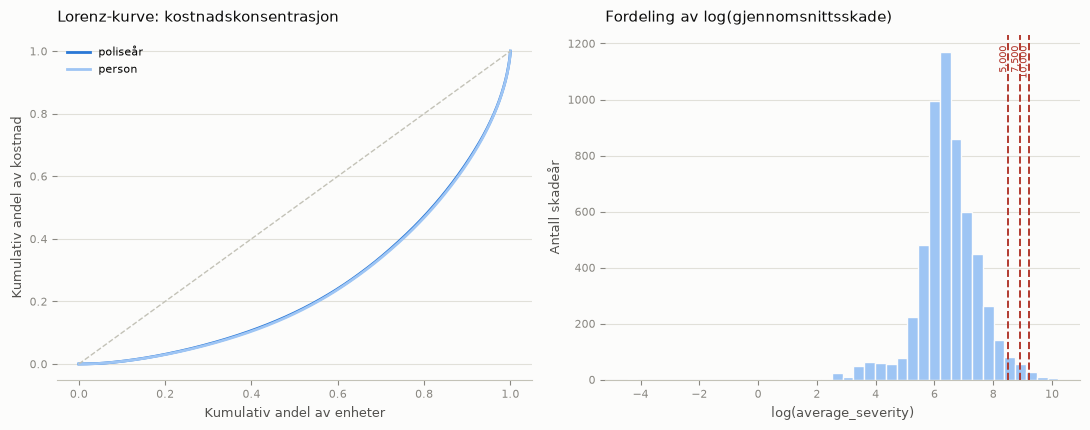

In [11]:
display(severity_descriptives.plot_cost_concentration(severity_frame))

**Konklusjon 3.1.** Kostnaden er skjev, men ikke dominert av enkeltobservasjoner:
de dyreste 1 % av skadeårene står for 8,5 % av kostnaden og de dyreste 10 % for
35,4 %, mens det dyreste enkeltåret (27 332 EUR) utgjør 0,31 %. Person- og
poliseårsnivå gir nesten identiske tall, som forventet når 5 698 skadeår fordeler
seg på 5 323 personer — konsentrasjonen skyldes dyre år, ikke personer med mange
skadeår. Av de 136 skadeårene over 5 000 EUR i gjennomsnittsskade ligger bare
6,1 % av totalkostnaden *over* selve terskelen. Vi kapper derfor ingenting: det
finnes ingen naturlig storskadegrense her, og Gamma-deviancen er uansett relativ,
slik at et dyrt år ikke automatisk dominerer scoren.

### 3.2 Små beløp og deviancens relative natur

Gamma-deviancen er relativ: et 10 %-avvik straffes like hardt ved 500 EUR
som ved 50 000 EUR, så små beløp kan i prinsippet drive scoren uten å bety
noe i kroner. Vi ser derfor på skadeår med svært lav gjennomsnittsskade,
de utelatte nær-null-årene, og eksakte beløpsklumper (mulige forhåndsavtalte
oppgjørsbeløp).

In [12]:
small_amount_tables = severity_descriptives.build_small_amount_table(
    severity_frame, model_frame
)
display(small_amount_tables["små_terskler"].round(4))
display(small_amount_tables["utelatte_nullår"])
display(small_amount_tables["beløpsklumper"].round(4))

,terskel,antall_skadeår,skadeantall,kostnadsandel
0,1,1,1,0.0
1,10,3,3,0.0


,antall_utelatte_poliseår,sum_registrerte_skader
0,9,10


,property_incurred,antall_skadeår,andel_skadeår
0,16.1115,21,0.0037
1,36.1790,6,0.0011
2,48.7025,5,0.0009
3,45.9195,4,0.0007
4,33.3960,4,0.0007
5,19.1935,3,0.0005
6,41.7450,3,0.0005
7,644.6555,3,0.0005
8,47.3110,3,0.0005
9,1085.2205,3,0.0005


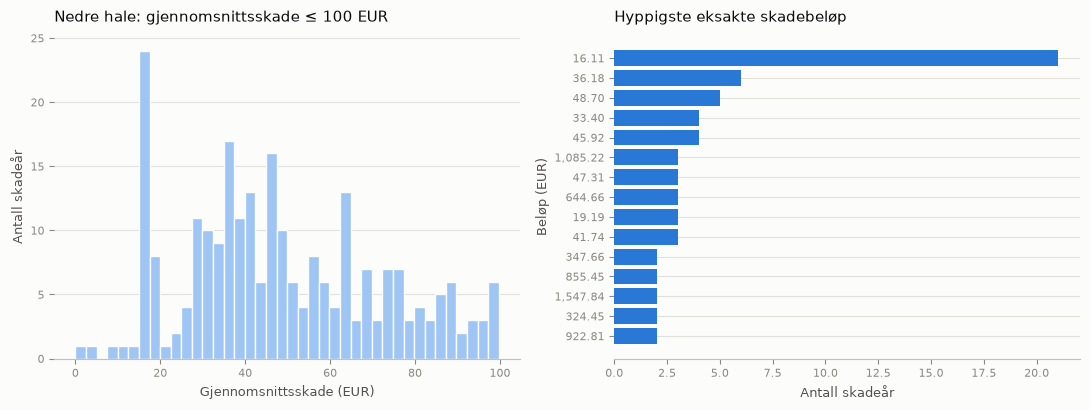

In [13]:
display(severity_descriptives.plot_small_amounts(severity_frame))

**Konklusjon 3.2.** Utelatelsesregelen (B-15) er praktisk talt kostnadsfri: bare
9 poliseår med til sammen 10 registrerte skader faller ut, altså 0,02 % av
modellpopulasjonen og 0,1 % av skadene. Det reelle forbeholdet ligger et annet
sted: beløpene klumper seg på eksakte verdier — 21 skadeår ligger på nøyaktig
16,11 EUR, og flere beløp (644,66, 1 085,22, 1 547,84 EUR) går igjen identisk.
Dette ser ut som faste oppgjørs- eller administrasjonsbeløp snarere enn
modellerbar skadekostnad. Siden Gamma-deviancen er relativ, teller et avvik på
16 EUR like mye per skade som et avvik på 16 000 EUR. Antallet er lite (~1 % av
radene), så virkningen på seleksjonen er begrenset, men dette føres som en
fortolkningsbegrensning — ikke som grunnlag for en ny filtreringsregel.

### 3.3 Kategoristøtte

Antall unike `insured_id` per nivå i hver kategoriske prediktor i
kandidatrommet (produkt, år, kommunetype, kjøresone, drivstoff, forretningstype,
betalingsfrekvens, pool'et merke, setekategori og skadeantallsgruppe), slik at
50-personerskravet i S-07 kan vurderes før første kandidatfit.

In [14]:
support_table = severity_descriptives.build_support_table(severity_frame)
display(support_table.round(4))

,variabel,nivå,antall_skadeår,unike_personer,skadeantall,kostnadsandel,skadevektet_severity,svakt_støttet
0,policy_type,COMP_E,3961,3744,5615,0.6591,1022.1694,False
1,policy_type,COMP_N,1737,1585,4364,0.3409,680.2564,False
2,year,2022,1722,1722,2822,0.3045,939.7782,False
3,year,2023,3976,3976,7157,0.6955,846.1738,False
4,municipality_type,C,1462,1357,2498,0.2631,917.3418,False
5,municipality_type,I,4034,3772,7179,0.7065,856.9800,False
6,municipality_type,IS,202,195,302,0.0304,875.3019,False
7,circulation_area,R,1966,1852,3219,0.3552,960.8148,False
8,circulation_area,U,3732,3471,6760,0.6448,830.6594,False
9,fuel_type,D,4358,4059,7729,0.7866,886.1949,False


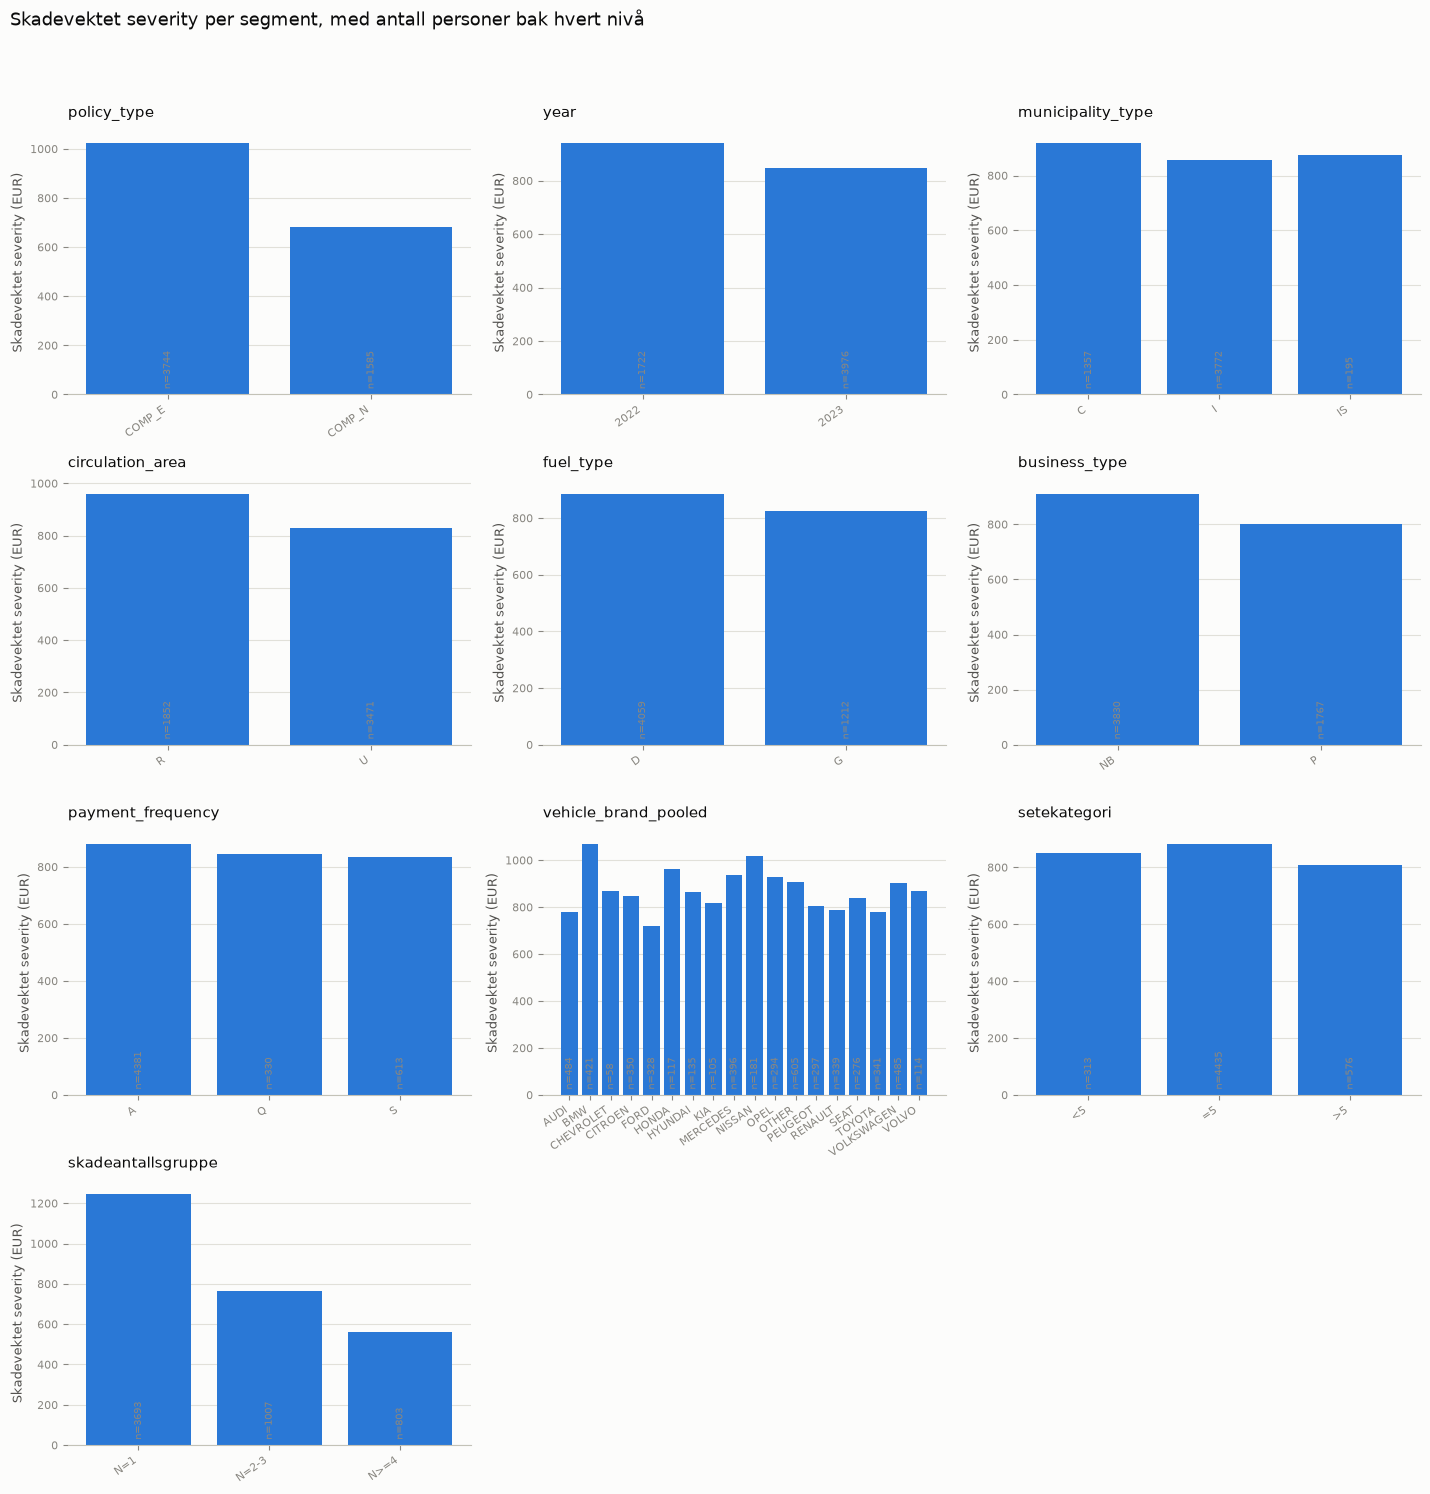

In [15]:
display(severity_descriptives.plot_support(severity_frame))

**Konklusjon 3.3.** Den samlede støttetabellen viser at enkelte nivåer i de
nye kategoriske feltene er små, selv om de øvrige kandidatvariablene har god
støtte. Den avgjørende kontrollen er foldvis treningsstøtte i designporten:
`fuel_type = MISSING` har 39–43 unike personer og `vehicle_brand_pooled =
CHEVROLET` har 42–50 i de fem treningsfoldene. FU1 og BR1 forkastes derfor før
fitting. Ingen ny pooling, kategorisering eller annen redningsregel brukes.

### 3.4 Foldvis kontroll av designmatrisene (S-10)

Før første kandidatfit bygges designmatrisene foldvis, og kategorinivåer,
referansenivåer, kolonneantall og rang kontrolleres mot kandidatregisteret.
Avvik håndteres etter gyldighetsreglene — implementeringen skal **ikke** stille
endre parametertall eller utelate nivåer for å få en kandidat til å passe.

In [16]:
design_checks = check_candidate_fold_design(
    severity_specs,
    severity_frame,
    cv_folds,
    prepare_fold_frames,
    prepare_design_frame,
    expected_parameters=PLAN_PARAMETERS,
    locked_references=BASE_LEVELS,
)
design_summary = summarize_candidate_design(design_checks)

prefit_checks = [
    "fem_folder",
    "kolonneantall_konstant",
    "alle_folder_full_rang",
    "alle_folder_støtte_ok",
    "alle_folder_referansenivåer_tilstede",
    "alle_folder_referansenivåer_samsvarer",
    "alle_folder_parametertall_ok",
]
design_summary["før_fit_gyldig"] = design_summary[prefit_checks].all(axis=1) & (
    design_summary["antall_avviste_folder"].eq(0)
)
design_summary["før_fit_status"] = np.where(
    design_summary["før_fit_gyldig"], "godkjent for fit", "forkastet før fit"
)
display(design_summary)

# Planens låste parametertall skal stemme eksakt — ingen justering ved avvik.
observed_columns = design_summary.set_index("kandidat")["kolonner"].to_dict()
for candidate, expected in PLAN_PARAMETERS.items():
    assert observed_columns[candidate] == expected, (
        candidate,
        observed_columns[candidate],
        expected,
    )
prefit_valid_candidates = set(
    design_summary.loc[design_summary["før_fit_gyldig"], "kandidat"]
)
prefit_rejected_candidates = set(design_summary["kandidat"]) - prefit_valid_candidates
expected_prefit_rejected = {"FU1", "BR1"}
assert prefit_rejected_candidates == expected_prefit_rejected, (
    prefit_rejected_candidates,
)
assert "S0" in prefit_valid_candidates, (
    "S0 er ugyldig etter før-fit-kontrollen; seleksjonsløpet stoppes."
)

# Hele registeret og designrapporten beholdes, men bare godkjente specs sendes
# til modellfitting. Ingen pooling eller annen redning gjøres for avviste specs.
severity_specs_for_fit = {
    name: severity_specs[name]
    for name in severity_specs
    if name in prefit_valid_candidates
}
assert len(severity_specs) * len(cv_folds) == 70
assert len(severity_specs_for_fit) * len(cv_folds) == 60

,kandidat,antall_folder,fem_folder,kolonner,kolonner_min,kolonner_maks,kolonneantall_konstant,min_rang,min_kategoristøtte,alle_folder_full_rang,alle_folder_støtte_ok,alle_folder_referansenivåer_tilstede,alle_folder_referansenivåer_samsvarer,alle_folder_parametertall_ok,antall_avviste_folder,før_fit_gyldig,før_fit_status
0,S0,5,True,9,9,9,True,9,145,True,True,True,True,True,0,True,godkjent for fit
1,A1,5,True,7,7,7,True,7,145,True,True,True,True,True,0,True,godkjent for fit
2,A2,5,True,8,8,8,True,8,145,True,True,True,True,True,0,True,godkjent for fit
3,A4,5,True,10,10,10,True,10,145,True,True,True,True,True,0,True,godkjent for fit
4,V3,5,True,11,11,11,True,11,145,True,True,True,True,True,0,True,godkjent for fit
5,G1,5,True,8,8,8,True,8,1239,True,True,True,True,True,0,True,godkjent for fit
6,G2,5,True,10,10,10,True,10,145,True,True,True,True,True,0,True,godkjent for fit
7,P1,5,True,10,10,10,True,10,145,True,True,True,True,True,0,True,godkjent for fit
8,P3,5,True,12,12,12,True,12,145,True,True,True,True,True,0,True,godkjent for fit
9,T1,5,True,11,11,11,True,11,145,True,True,True,True,True,0,True,godkjent for fit


**Konklusjon 3.4.** Alle 14 designene hadde konstant og korrekt
kolonneantall (7–26), full rang, låste referanser og fem komplette folder.
FU1 ble likevel forkastet før fit fordi `fuel_type = MISSING` bare hadde
39–43 unike personer i treningsfoldene. BR1 ble også forkastet: `CHEVROLET`
hadde 42–50 personer og lå under 50-kravet i fire folder. De øvrige tolv
spesifikasjonene besto porten; ingen pooling eller annen redning ble forsøkt.

## 4. Låst Gamma-løp

Seleksjonsalgoritmen (S-09) kjøres nå én gang. Resultatene fra alle kandidater
lagres, og søket avsluttes etter algoritmen — også dersom konklusjonen blir at
S0 beholdes. Kandidater forkastet i før-fit-porten står i designrapporten, men
fittes ikke. Budsjettet er 70/75 som protokollmaksimum; faktisk budsjett er
antallet godkjente faste specs ganger fem, pluss eventuell C1.

### 4.1 Kjøring av de godkjente faste spesifikasjonene

In [17]:
# Hver kandidat kjøres én gang over de fem låste foldene. fold_hook lagrer i
# tillegg prediksjoner for hele modellpopulasjonen (S-11), til bruk i seksjon 5.
full_population_hook = make_full_population_hook(model_frame, severity_frame, cv_folds)
severity_results, fits_used = run_candidates(
    severity_specs_for_fit,
    severity_frame,
    cv_folds,
    FIT_SETTINGS,
    fold_hook=full_population_hook,
)
assert fits_used == len(severity_specs_for_fit) * len(cv_folds)
assert fits_used == 60, fits_used
print(f"hovedtilpasninger brukt: {fits_used} av protokollmaksimum 70")

hovedtilpasninger brukt: 60 av protokollmaksimum 70


In [18]:
score_table = build_score_table(severity_results, severity_frame, PLAN_PARAMETERS)
display(score_table.round(6))

# Gyldighetskravene i S-07: konvergens i alle folder og OOF-prediksjon på alle
# 5 698 skadeårene. Kandidater som faller her, kan ikke sammenlignes videre.
# Før-fit-forkastede kandidater er ikke med i denne tabellen og kan derfor ikke
# komme inn i senere kvalifisering eller blokkvalg.
valid_candidates = set(score_table.loc[score_table["gyldig"], "ID"])
if "S0" not in valid_candidates:
    raise RuntimeError(
        "S0 er ugyldig etter femfoldskontrollen; seleksjonsløpet stoppes "
        "uten parvise sammenligninger eller finalistvalg."
    )
assert valid_candidates, "ingen gyldige kandidater"

,ID,parametere,parametere_plan,pooled_deviance,fold_min,fold_maks,rader_oof,alle_konvergerte,gyldig,feil
0,G1,8,8,0.725493,0.664128,0.764725,5698,True,True,None
1,BU1,10,10,0.727559,0.666842,0.765231,5698,True,True,None
2,T1,11,11,0.727654,0.668645,0.766923,5698,True,True,None
3,G2,10,10,0.727852,0.663593,0.765453,5698,True,True,None
4,A1,7,7,0.728269,0.668283,0.764626,5698,True,True,None
5,A2,8,8,0.728461,0.668281,0.764669,5698,True,True,None
6,A4,10,10,0.728467,0.667956,0.767092,5698,True,True,None
7,S0,9,9,0.729006,0.668240,0.766679,5698,True,True,None
8,PF1,11,11,0.729240,0.669807,0.766704,5698,True,True,None
9,V3,11,11,0.729605,0.668305,0.767299,5698,True,True,None


In [19]:
fold_deviance_table = build_fold_deviance_table(severity_results)
display(fold_deviance_table.round(6))

,S0,A1,A2,A4,V3,G1,G2,P1,P3,T1,BU1,PF1
fold,,,,,,,,,,,,
gruppe_1,0.735792,0.736304,0.735854,0.734094,0.736287,0.727934,0.729390,0.736053,0.735445,0.736063,0.732870,0.735319
gruppe_2,0.764088,0.764626,0.764139,0.765404,0.766499,0.764725,0.765453,0.767021,0.767118,0.760410,0.765133,0.764106
gruppe_3,0.711704,0.709362,0.710885,0.709230,0.711153,0.708156,0.717258,0.711364,0.712420,0.707530,0.709220,0.711685
gruppe_4,0.766679,0.764306,0.764669,0.767092,0.767299,0.764024,0.765228,0.768461,0.770581,0.766923,0.765231,0.766704
gruppe_5,0.668240,0.668283,0.668281,0.667956,0.668305,0.664128,0.663593,0.667104,0.667764,0.668645,0.666842,0.669807


**Konklusjon 4.1.** Alle tolv fittede spesifikasjoner konvergerte i samtlige
folder og ga OOF-prediksjon for alle 5 698 skadeår. Pooled deviance lå fra
0,725493 (G1) til 0,730374 (P3); foldscorene spente fra 0,663593 til
0,770581. S0 var gyldig med 0,729006 og foldintervall 0,668240–0,766679.
FU1 og BR1 står i designrapporten som før-fit-forkastet og har derfor ingen
score.

### 4.2 Kvalifisering av de godkjente enkeltutfordrerne mot S0

In [20]:
challengers = [name for name in CANDIDATE_TERMS if name != "S0" and name in valid_candidates]
qualification_records = qualify_against(
    severity_results, severity_frame, "S0", challengers, PLAN_PARAMETERS, qualifies
)
selection_table = build_selection_table(qualification_records)
display(selection_table.round(6))

,ID,Parametere,Pooled deviance,Gevinst mot referanse,SE,Terskel,Regel,Folder forbedret,Kvalifiserer
0,A1,7,0.728269,0.000736,0.000867,0.000867,forenkling,2,True
1,A2,8,0.728461,0.000545,0.000334,0.000334,forenkling,2,True
2,A4,10,0.728467,0.000538,0.001022,0.003645,forbedring,3,False
3,V3,11,0.729605,-0.000599,0.000532,0.003645,forbedring,1,False
4,G1,8,0.725493,0.003512,0.001929,0.001929,forenkling,4,True
5,G2,10,0.727852,0.001154,0.001636,0.003645,forbedring,3,False
6,P1,10,0.729694,-0.000688,0.000810,0.003645,forbedring,2,False
7,P3,12,0.730374,-0.001368,0.000976,0.003645,forbedring,2,False
8,T1,11,0.727654,0.001351,0.001309,0.003645,forbedring,2,False
9,BU1,10,0.727559,0.001446,0.001123,0.003645,forbedring,4,False


**Konklusjon 4.2.** A1, A2 og G1 kvalifiserte etter forenklingsregelen. A1
og A2 hadde henholdsvis gevinst 0,000736 og 0,000545, med bindende
SE-grenser 0,000867 og 0,000334; begge forbedret 2/5 folder. G1 hadde gevinst
0,003512, bindende SE 0,001929 og forbedret 4/5 folder. BU1 forbedret 4/5
folder, men gevinsten 0,001446 nådde ikke 0,5 %-kravet 0,003645. PF1 tapte
0,000235 og forbedret 2/5; heller ikke A4, V3, G2, P1, P3 eller T1
kvalifiserte. FU1 og BR1 var allerede forkastet på støtte.

### 4.3 Geografisærregelen: G2 mot både S0 og G1

G2 kvalifiserer bare hvis den består forbedringsregelen mot **både** S0 og G1 på
de samme fem foldene. G1 må være gyldig for å være sammenligningsgrunnlag, men
trenger ikke selv kvalifisere mot S0.

In [21]:
def rule_arguments(reference, candidate):
    """Pakk en parvis sammenligning om til argumentene `qualifies` krever."""
    comparison = compare_pair(severity_results, severity_frame, reference, candidate)
    return {
        "gain": comparison["gevinst"],
        "se_pair": comparison["SE_cluster"],
        "reference_deviance": comparison["D_referanse"],
        "folds_improved": comparison["folder_forbedret"],
        "n_folds": comparison["n_folder"],
        "candidate_parameters": PLAN_PARAMETERS[candidate],
        "reference_parameters": PLAN_PARAMETERS[reference],
    }


if "G2" in valid_candidates:
    geography = apply_geography_rule(
        rule_arguments("S0", "G2"),
        rule_arguments("G1", "G2") if "G1" in valid_candidates else None,
        g1_valid="G1" in valid_candidates,
    )
else:
    geography = {
        "kvalifiserer": False,
        "begrunnelse": "G2 er ugyldig og forkastes før geografisærregelen.",
    }
print(geography["begrunnelse"])

G2 består verken kravet mot S0 eller mot G1: kvalifiserer ikke.


In [22]:
# Kvalifiserte enkeltutfordrere: tabellen over, men med G2 overstyrt av særregelen.
qualified = {
    record["id"]
    for record in qualification_records
    if record["qualifies_result"]["kvalifiserer"]
}
qualified.discard("G2")
if geography["kvalifiserer"]:
    qualified.add("G2")
print("kvalifiserte enkeltutfordrere:", sorted(qualified) or "ingen")

kvalifiserte enkeltutfordrere: ['A1', 'A2', 'G1']


**Konklusjon 4.3.** G2 kvalifiserte ikke mot S0 og besto heller ikke kravet
mot G1. Den kunne derfor ikke overstyre geografiblokken. G1 var gyldig og
forble det eneste kvalifiserte geografialternativet.

### 4.4 Blokkvalg

Ett alternativ velges i hver av de ni blokkene (alder, verdi, geografi, ytelse,
seter, drivstoff, forretningstype, betalingsfrekvens og merke). S0 representerer
uendret blokk og er alltid med som alternativ, slik at
en blokk bare endres når en kvalifisert utfordrer også vinner nesten-like-regelen.

In [23]:
BLOCKS = {
    "alder": ["A1", "A2", "A4"],
    "verdi": ["V3"],
    "geografi": ["G1", "G2"],
    "ytelse": ["P1", "P3"],
    "seter": ["T1"],
    "drivstoff": ["FU1"],
    "forretningstype": ["BU1"],
    "betaling": ["PF1"],
    "merke": ["BR1"],
}

block_choices = {}
for block, members in BLOCKS.items():
    options = ["S0"] + [name for name in members if name in qualified]
    choice = near_tie_choice(
        severity_results, severity_frame, options, PLAN_PARAMETERS, choose_near_tie
    )
    block_choices[block] = choice["valgt"]
    print(f"{block:9s} alternativer={options} -> {choice['valgt']}  ({choice['begrunnelse']})")

alder     alternativer=['S0', 'A1', 'A2'] -> A1  (A1 valgt blant 3 nesten like kandidater: færrest parametere (7).)
verdi     alternativer=['S0'] -> S0  (S0 valgt: eneste kandidat innenfor 1 SE og 0.5% av beste score (0.729006).)
geografi  alternativer=['S0', 'G1'] -> G1  (G1 valgt: eneste kandidat innenfor 1 SE og 0.5% av beste score (0.725493).)
ytelse    alternativer=['S0'] -> S0  (S0 valgt: eneste kandidat innenfor 1 SE og 0.5% av beste score (0.729006).)
seter     alternativer=['S0'] -> S0  (S0 valgt: eneste kandidat innenfor 1 SE og 0.5% av beste score (0.729006).)
drivstoff alternativer=['S0'] -> S0  (S0 valgt: eneste kandidat innenfor 1 SE og 0.5% av beste score (0.729006).)
forretningstype alternativer=['S0'] -> S0  (S0 valgt: eneste kandidat innenfor 1 SE og 0.5% av beste score (0.729006).)
betaling  alternativer=['S0'] -> S0  (S0 valgt: eneste kandidat innenfor 1 SE og 0.5% av beste score (0.729006).)
merke     alternativer=['S0'] -> S0  (S0 valgt: eneste kandidat innenfor 1

In [24]:
changed_blocks = {b: c for b, c in block_choices.items() if c != "S0"}
print("endrede blokker:", changed_blocks or "ingen")

endrede blokker: {'alder': 'A1', 'geografi': 'G1'}


**Konklusjon 4.4.** Aldersblokken valgte A1 blant S0/A1/A2 fordi alle tre var
nesten like og A1 hadde færrest parametere. Geografiblokken valgte G1, som
alene lå innenfor begge nesten-like-grensene rundt blokkens beste score.
Verdi, ytelse, seter, drivstoff, forretningstype, betaling og merke beholdt
S0. De to endrede blokkene var dermed lineær alder og kjøresone i stedet for
kommunetype.

### 4.5 Kombinert kandidat C1

Dersom minst to blokker endres, bygges **én** samlet kandidat C1 — ingen andre
kombinasjoner tillates. C1 må bestå den relevante forbedrings-/forenklingsregelen
mot S0 og mot hver valgt enkeltutfordrer, og reglene anvendes ut fra
parametertallet i hvert enkelt sammenligningspar. Forkastes C1, brukes de
allerede kvalifiserte enkeltmodellene som fallback; C1 splittes ikke opp i en ny
kombinasjonsrunde.

In [25]:
def combine_terms(chosen):
    """Slå blokkendringene sammen til én termliste, uttrykt som diff mot S0."""
    terms = list(S0_TERMS)
    for name in chosen:
        candidate_terms = CANDIDATE_TERMS[name]
        removed = [term for term in S0_TERMS if term not in candidate_terms]
        added = [term for term in candidate_terms if term not in S0_TERMS]
        terms = [term for term in terms if term not in removed]
        terms += [term for term in added if term not in terms]
    return terms


candidate_parameters = dict(PLAN_PARAMETERS)
chosen_challengers = sorted(set(changed_blocks.values()))
build_c1 = len(changed_blocks) >= 2
c1_pre_fit_valid = False
print("C1 bygges" if build_c1 else "C1 bygges ikke: færre enn to blokker endret")

C1 bygges


In [26]:
if build_c1:
    c1_terms = combine_terms(chosen_challengers)
    c1_expected_parameters = PLAN_PARAMETERS["S0"] + sum(
        PLAN_PARAMETERS[name] - PLAN_PARAMETERS["S0"] for name in chosen_challengers
    )
    candidate_parameters["C1"] = c1_expected_parameters
    severity_specs["C1"] = glm_spec(
        "C1", c1_terms, "average_severity", severity_frame, GAMMA_FAMILY,
        "property_claims", GAMMA_POWER, required_columns=raw_columns(c1_terms),
        base_level_overrides=BASE_LEVELS,
    )
    # Samme gyldighetsport som de 14 faste kandidatene, før C1 fittes.
    c1_design = summarize_candidate_design(
        check_candidate_fold_design(
            {"C1": severity_specs["C1"]}, severity_frame, cv_folds,
            prepare_fold_frames,
            prepare_design_frame,
            expected_parameters={"C1": c1_expected_parameters},
            locked_references=BASE_LEVELS,
        )
    )
    display(c1_design)
    print("C1-termer:", c1_terms)
    c1_pre_fit_valid = bool(
        len(c1_design) == 1
        and c1_design["fem_folder"].iloc[0]
        and c1_design["kolonneantall_konstant"].iloc[0]
        and c1_design["alle_folder_full_rang"].iloc[0]
        and c1_design["alle_folder_støtte_ok"].iloc[0]
        and c1_design["alle_folder_referansenivåer_tilstede"].iloc[0]
        and c1_design["alle_folder_referansenivåer_samsvarer"].iloc[0]
        and c1_design["alle_folder_parametertall_ok"].iloc[0]
        and c1_design["antall_avviste_folder"].iloc[0] == 0
    )
    if not c1_pre_fit_valid:
        print("C1 forkastes før fit: designmatrisen besto ikke før-fit-porten")

,kandidat,antall_folder,fem_folder,kolonner,kolonner_min,kolonner_maks,kolonneantall_konstant,min_rang,min_kategoristøtte,alle_folder_full_rang,alle_folder_støtte_ok,alle_folder_referansenivåer_tilstede,alle_folder_referansenivåer_samsvarer,alle_folder_parametertall_ok,antall_avviste_folder
0,C1,5,True,6,6,6,True,6,1239,True,True,True,True,True,0


C1-termer: ['policy_type', 'year', 'log_vehicle_value', 'driver_age', 'circulation_area']


In [27]:
if build_c1 and c1_pre_fit_valid:
    c1_results, c1_fits = run_candidates(
        {"C1": severity_specs["C1"]}, severity_frame, cv_folds, FIT_SETTINGS,
        fold_hook=full_population_hook,
    )
    severity_results.update(c1_results)
    fits_used += c1_fits
    display(build_score_table(severity_results, severity_frame, candidate_parameters))
    actual_budget_max = len(severity_specs_for_fit) * len(cv_folds) + len(cv_folds)
    print(
        f"hovedtilpasninger brukt totalt: {fits_used} "
        f"av faktisk maks {actual_budget_max} (protokollmaksimum 75)"
    )
    assert fits_used <= actual_budget_max, fits_used
    assert fits_used <= 75, fits_used

,ID,parametere,parametere_plan,pooled_deviance,fold_min,fold_maks,rader_oof,alle_konvergerte,gyldig,feil
0,C1,6,6,0.724835,0.664086,0.764927,5698,True,True,None
1,G1,8,8,0.725493,0.664128,0.764725,5698,True,True,None
2,BU1,10,10,0.727559,0.666842,0.765231,5698,True,True,None
3,T1,11,11,0.727654,0.668645,0.766923,5698,True,True,None
4,G2,10,10,0.727852,0.663593,0.765453,5698,True,True,None
5,A1,7,7,0.728269,0.668283,0.764626,5698,True,True,None
6,A2,8,8,0.728461,0.668281,0.764669,5698,True,True,None
7,A4,10,10,0.728467,0.667956,0.767092,5698,True,True,None
8,S0,9,9,0.729006,0.668240,0.766679,5698,True,True,None
9,PF1,11,11,0.729240,0.669807,0.766704,5698,True,True,None


hovedtilpasninger brukt totalt: 65 av faktisk maks 65 (protokollmaksimum 75)


In [28]:
if build_c1 and c1_pre_fit_valid:
    # C1 må bestå regelen mot S0 OG mot hver valgt enkeltutfordrer.
    c1_records = qualify_against(
        severity_results, severity_frame, "S0", ["C1"], candidate_parameters, qualifies,
    )
    for reference in chosen_challengers:
        c1_records += qualify_against(
            severity_results, severity_frame, reference, ["C1"],
            candidate_parameters, qualifies,
        )
    c1_table = build_selection_table(c1_records)
    c1_table.insert(1, "Referanse", ["S0", *chosen_challengers])
    display(c1_table.round(6))
    c1_qualifies = bool(c1_table["Kvalifiserer"].all())
else:
    c1_qualifies = False
print("C1 kvalifiserer:", c1_qualifies)

,ID,Referanse,Parametere,Pooled deviance,Gevinst mot referanse,SE,Terskel,Regel,Folder forbedret,Kvalifiserer
0,C1,S0,6,0.724835,0.004170,0.002203,0.002203,forenkling,4,True
1,C1,A1,6,0.724835,0.003434,0.001844,0.001844,forenkling,4,True
2,C1,G1,6,0.724835,0.000658,0.000649,0.000649,forenkling,3,True


C1 kvalifiserer: True


**Konklusjon 4.5.** C1 kombinerte produkt, år, lineær log-bilverdi, lineær
føreralder og kjøresone. Designet hadde seks parametere, full rang og minste
foldstøtte 1 239. Pooled deviance var 0,724835. C1 kvalifiserte mot S0
(gevinst 0,004170; SE 0,002203), A1 (0,003434; 0,001844) og G1
(0,000658; 0,000649) etter den parvise forenklingsregelen. Det ble brukt 65
hovedfits: 60 faste og fem for C1, mot protokollmaksimum 75.

### 4.6 Finalist

Finalisten velges blant S0, de kvalifiserte enkeltutfordrerne og en eventuell
kvalifisert C1, med den samme nesten-like-regelen: færrest parametere først,
deretter lavest deviance, deretter alfabetisk ID.

In [29]:
finalist_options = ["S0", *sorted(qualified)] + (["C1"] if c1_qualifies else [])
finalist_choice = near_tie_choice(
    severity_results, severity_frame, finalist_options, candidate_parameters,
    choose_near_tie,
)
display(finalist_choice["tabell"].round(6))
FINALIST = finalist_choice["valgt"]
print(f"Finalist: {FINALIST} — {finalist_choice['begrunnelse']}")
print("Nesten like:", finalist_choice["nesten_like"])

,id,parameters,deviance,se_pair,avstand_deviance,avstand_i_se,avstand_i_prosent,nesten_likt
0,S0,9,0.729006,0.002203,0.004170,1.893238,0.575372,False
1,A1,7,0.728269,0.001844,0.003434,1.862053,0.473810,False
2,A2,8,0.728461,0.002045,0.003626,1.773048,0.500204,False
3,G1,8,0.725493,0.000649,0.000658,1.014280,0.090801,False
4,C1,6,0.724835,NaN,0.000000,0.000000,0.000000,True


Finalist: C1 — C1 valgt: eneste kandidat innenfor 1 SE og 0.5% av beste score (0.724835).
Nesten like: ['C1']


**Konklusjon 4.6.** C1 ble finalist og var alene innenfor både én parvis SE
og 0,5 % av beste score. G1 lå bare 0,000658 bak, men dette var marginalt mer
enn parvis SE 0,000649; A2 lå 0,500204 % bak og falt så vidt utenfor
prosentgrensen. C1s gevinst mot S0 var 0,004170, tilsvarende 0,57 % av S0s
deviance. Dette er en utviklingsgevinst etter seleksjon på de samme foldene,
ikke en uavhengig vurdering av hele seleksjonsprosedyren.

### 4.7 Resultater fra det reviderte kandidatløpet

Denne seksjonen skal skrives etter den nye kjøringen. Den skal samle den
endelige seleksjonskonklusjonen og forklare hvordan drivstoff,
`business_type`, betalingsfrekvens og pool'et bilmerke påvirket
kandidatvalget. Ingen tidligere finalist eller score skal kopieres inn uten
at den er reprodusert av den reviderte protokollen.

**Samlet seleksjonsresultat.** De fire nye feltene endret ikke finalisten:
FU1 og BR1 ble forkastet før fit på støtte, mens BU1 og PF1 var gyldige, men
kvalifiserte ikke mot S0. Det låste løpet valgte i stedet C1 med lineær alder
og kjøresone. Bare denne ene kombinasjonen ble prøvd; ingen ny kandidat- eller
delkombinasjonsrunde ble åpnet etter resultatinnsyn.

## 5. Diagnostikk etter seleksjon

In [30]:
# Finalistvalget er avsluttet: diagnostikken bruker bare disse faste OOF-
# prediksjonene og åpner ikke kandidatregisteret på nytt.
FINALIST_LABEL = FINALIST if FINALIST != "S0" else "S0_finalist"
FIXED_OOF_PREDICTIONS = {
    "S0": severity_results["S0"]["oof"].reindex(severity_frame.index),
    FINALIST_LABEL: severity_results[FINALIST]["oof"].reindex(severity_frame.index),
}
assert all(pred.notna().all() for pred in FIXED_OOF_PREDICTIONS.values())

### 5.1 A/E-kalibrering og prediksjonsdesiler

A/E er faktisk kostnad delt på forventet kostnad
$\sum_i N_i\hat\mu_i$. Desilene defineres én gang fra S0s OOF-prediksjon,
skadeantallsvektet, og brukes uendret for finalisten. `N=1` er et selektert utvalg av
skadeår — ikke nødvendigvis én fysisk hendelse.

In [31]:
CALIBRATION_SEGMENTS = [
    "policy_type",
    "year",
    "municipality_type",
    "circulation_area",
    "fuel_type",
    "business_type",
    "payment_frequency",
    "vehicle_brand_pooled",
]
calibration_ae = severity_calibration.build_ae_table(
    severity_frame, FIXED_OOF_PREDICTIONS, CALIBRATION_SEGMENTS
)
calibration_deciles = severity_calibration.build_decile_table(
    severity_frame, FIXED_OOF_PREDICTIONS, reference_model="S0"
)

In [32]:
calibration_report = pd.concat(
    [
        calibration_ae.assign(
            output="A/E-segment", desil=pd.NA, faktisk_severity=pd.NA,
            gjennomsnitt_predikert=pd.NA,
        ),
        calibration_deciles.assign(
            output="S0-desil", variabel="S0_prediksjonsdesil",
            nivå=calibration_deciles["desil"],
        ),
    ],
    ignore_index=True,
    sort=False,
)
display(
    calibration_report[
        [
            "output", "variabel", "nivå", "modell", "unike_personer",
            "skadeantall", "A_E", "gjennomsnitt_predikert",
            "faktisk_severity",
        ]
    ].round(4)
)

,output,variabel,nivå,modell,unike_personer,skadeantall,A_E,gjennomsnitt_predikert,faktisk_severity
0,A/E-segment,Totalt,Totalt,S0,5323,9979,1.0006,<NA>,<NA>
1,A/E-segment,Totalt,Totalt,C1,5323,9979,1.0003,<NA>,<NA>
2,A/E-segment,policy_type,COMP_E,S0,3744,5615,0.9999,<NA>,<NA>
3,A/E-segment,policy_type,COMP_E,C1,3744,5615,1.0000,<NA>,<NA>
4,A/E-segment,policy_type,COMP_N,S0,1585,4364,1.0019,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...
97,S0-desil,S0_prediksjonsdesil,8,S0,738,998,1.0467,1030.530501,1078.629456
98,S0-desil,S0_prediksjonsdesil,9,C1,676,998,0.9203,1070.547329,985.20538
99,S0-desil,S0_prediksjonsdesil,9,S0,676,998,0.9151,1076.64998,985.20538
100,S0-desil,S0_prediksjonsdesil,10,C1,664,998,0.9787,1157.468221,1132.823102


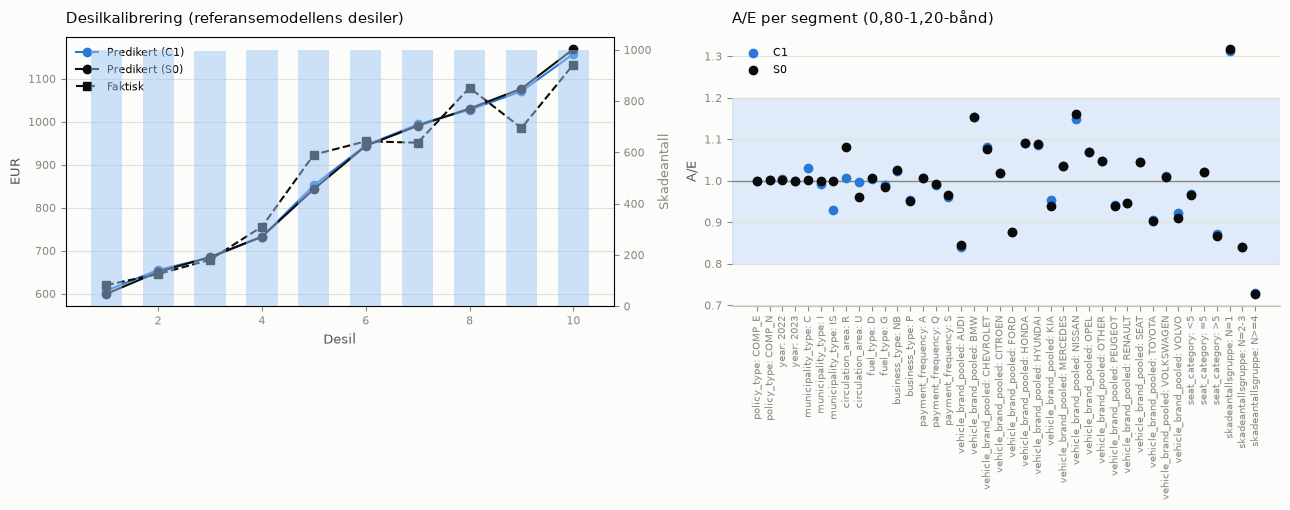

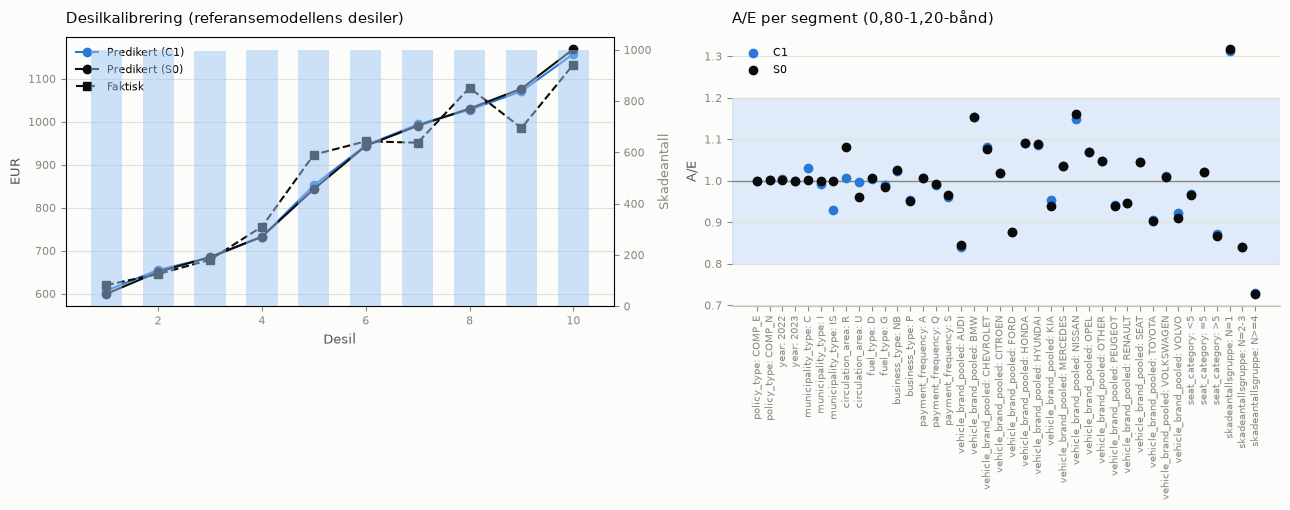

In [33]:
display(severity_calibration.plot_calibration(calibration_deciles, calibration_ae))

**Konklusjon 5.1.** Total OOF A/E var 1,0003 for C1 og 1,0006 for S0;
produktnivåene lå også nær 1. C1s S0-desiler spente fra 0,9203 i desil 9 til
1,0841 i desil 5. Desil 9s intervall utelukket 1, men punktet var innenfor
materialitetsbåndet 0,80–1,20, så dette utløste ikke EUR-stopp. `N=1` er et
selektert skadeårssegment og ikke nødvendigvis én fysisk hendelse.

### 5.2 Beløpsklasser og foldstabilitet

Beløpsklassene er faste og diagnostiske. De endrer ikke responsen eller åpner
nye kandidatspesifikasjoner. Foldstabiliteten beskriver hvor mye de allerede
estimerte effektene flytter seg mellom de fem hovedfoldene.

#### 5.2a Beløpsklasser

In [34]:
contribution_table = severity_calibration.build_contribution_table(
    severity_frame, FIXED_OOF_PREDICTIONS
)
display(contribution_table.round(4))

,beløpsklasse,modell,antall_skadeår,skadeantall,andel_skadeantall,kostnadsandel,deviance_bidrag,deviance_andel,eur_feil,eur_feil_andel
0,≤1,S0,1,1,0.0001,0.0000,20.5154,0.0028,-8.909485e+02,-0.1757
1,"(1, 10]",S0,2,2,0.0002,0.0000,17.1878,0.0024,-1.926490e+03,-0.3799
2,"(10, 100]",S0,247,276,0.0277,0.0015,1202.4225,0.1653,-2.521104e+05,-49.7116
3,"(100, 1000]",S0,3814,7660,0.7676,0.4615,2759.7849,0.3794,-2.482537e+06,-489.5109
4,"(1000, 5000]",S0,1498,1899,0.1903,0.3947,1529.7643,0.2103,1.642183e+06,323.8085
5,>5000,S0,136,141,0.0141,0.1423,1745.0716,0.2399,1.100353e+06,216.9695
6,≤1,C1,1,1,0.0001,0.0000,20.4482,0.0028,-8.614732e+02,-0.3900
7,"(1, 10]",C1,2,2,0.0002,0.0000,17.4679,0.0024,-2.067235e+03,-0.9358
8,"(10, 100]",C1,247,276,0.0277,0.0015,1205.2211,0.1666,-2.535703e+05,-114.7835
9,"(100, 1000]",C1,3814,7660,0.7676,0.4615,2754.2264,0.3808,-2.476163e+06,-1120.8829


#### 5.2b Foldstabilitet og numerisk korrelasjon

In [35]:
stability_table = severity_calibration.build_fold_coefficient_table(
    severity_results, list(dict.fromkeys(["S0", FINALIST]))
)
correlation_input = severity_frame.dropna(
    subset=["driver_age", "log_vehicle_value"]
)
correlation_table = severity_calibration.build_numeric_correlation_table(
    correlation_input, ["driver_age", "log_vehicle_value"]
)
driver_value_correlation = correlation_table.loc[
    correlation_table["variabel_1"].eq("driver_age")
    & correlation_table["variabel_2"].eq("log_vehicle_value"),
    "korrelasjon",
].iloc[0]
display(stability_table.round(4))
print(f"Vektet korr(driver_age, log_vehicle_value) = {driver_value_correlation:.6f}")

,modell,koeffisient,fold_min,fold_maks,gjennomsnitt,standardavvik,relativ_spredning
0,S0,Intercept,4.5029,5.5368,4.9952,0.3866,0.2070
1,S0,"C(policy_type, Treatment('COMP_E'))[T.COMP_N]",-0.4244,-0.3883,-0.4084,0.0155,0.0886
2,S0,"C(year, Treatment(2022))[T.2023]",-0.1149,-0.0653,-0.0876,0.0194,0.5660
3,S0,"C(municipality_type, Treatment('I'))[T.C]",0.0002,0.0429,0.0282,0.0184,1.5144
4,S0,"C(municipality_type, Treatment('I'))[T.IS]",-0.1955,0.0612,-0.0425,0.0950,6.0411
5,S0,"cr(driver_age, df=3, constraints='center')[0]",-0.0607,0.0953,0.0042,0.0582,37.0416
6,S0,"cr(driver_age, df=3, constraints='center')[1]",-0.0462,0.0346,-0.0201,0.0337,4.0163
7,S0,"cr(driver_age, df=3, constraints='center')[2]",-0.3029,-0.0831,-0.1583,0.0884,1.3885
8,S0,log_vehicle_value,0.1378,0.2368,0.1914,0.0376,0.5175
9,C1,Intercept,4.4733,5.4955,4.9394,0.4060,0.2070


Vektet korr(driver_age, log_vehicle_value) = -0.012917


**Konklusjon 5.2.** C1s produkt-, års- og bilverdieffekter hadde samme fortegn
i alle folder. Kjøresonerelativiteten var også stabil i retning
(koeffisient 0,0699–0,1321), mens lineær alder lå nær null
(-0,0019–0,0000) og er svakt identifisert som egen effekt. Skadevektet
korrelasjon mellom alder og log-bilverdi var bare -0,0129, så disse to
numeriske leddene viser ingen materiell lineær samvariasjon. Beløp ≤1 EUR sto
for 0,28 % av C1-deviancen og under 0,1 % av kostnaden; småbeløpsstoppet ble
ikke utløst. Foldspredningen beskriver likevel bare fem tilpasninger og gjør
ikke koeffisientene kausale.

### 5.3 Cluster-bootstrap og EUR-stopp

Bootstrapen bruker 2 000 cluster-trekk på `insured_id` med seed 410 og faste
OOF-prediksjoner. Den refitter ikke modeller og gjentar ikke seleksjonen. Først
bygges S0-desilene på samme skadeantallsvektede grunnlag som i kalibreringen.

In [36]:
decile_order = FIXED_OOF_PREDICTIONS["S0"].sort_values().index
decile_claim_share = severity_frame.loc[decile_order, "property_claims"].cumsum()
s0_deciles = pd.Series(
    np.ceil(
        decile_claim_share.to_numpy()
        / severity_frame.loc[decile_order, "property_claims"].sum()
        * severity_calibration.N_DECILES
    ).clip(max=severity_calibration.N_DECILES).astype(int),
    index=decile_order,
    name="S0_desil",
).reindex(severity_frame.index)

In [37]:
bootstrap_deviance = severity_bootstrap.bootstrap_deviance_ci(
    severity_frame, FIXED_OOF_PREDICTIONS, n_draws=2000, seed=410
)
bootstrap_gain = severity_bootstrap.bootstrap_gain_ci(
    severity_frame,
    FIXED_OOF_PREDICTIONS,
    "S0",
    FINALIST_LABEL,
    n_draws=2000,
    seed=410,
)

In [38]:
bootstrap_ae = severity_bootstrap.bootstrap_ae_ci(
    severity_frame,
    FIXED_OOF_PREDICTIONS,
    n_draws=2000,
    seed=410,
    extra_segments={"S0_desil": s0_deciles},
)
bootstrap_stops = severity_bootstrap.evaluate_stop_criteria(bootstrap_ae)
bootstrap_key_ae = bootstrap_ae.loc[
    bootstrap_ae["variabel"].isin(["Totalt", "policy_type", "S0_desil"])
].copy()

In [39]:
bootstrap_report = bootstrap_key_ae.rename(
    columns={"A_E": "punkt", "utelukker_1": "CI_utelukker_1"}
).assign(mål="A/E")
bootstrap_report = bootstrap_report[
    ["mål", "modell", "variabel", "nivå", "punkt", "lav", "høy", "CI_utelukker_1"]
]
deviance_report = bootstrap_deviance.assign(
    mål="Deviance", variabel="Totalt", nivå="Totalt",
    CI_utelukker_1=pd.NA,
).rename(columns={"punkt": "punkt"})[
    ["mål", "modell", "variabel", "nivå", "punkt", "lav", "høy", "CI_utelukker_1"]
]
gain_report = pd.DataFrame(
    [{
        "mål": f"Gevinst S0-{FINALIST}", "modell": FINALIST_LABEL,
        "variabel": "Totalt",
        "nivå": "Totalt", "punkt": bootstrap_gain["punkt"],
        "lav": bootstrap_gain["lav"], "høy": bootstrap_gain["høy"],
        "CI_utelukker_1": pd.NA,
    }]
)
display(pd.concat([deviance_report, gain_report, bootstrap_report], ignore_index=True).round(6))
print("EUR-stopp utløst:", bool(bootstrap_stops["utløst"].any()))

,mål,modell,variabel,nivå,punkt,lav,høy,CI_utelukker_1
0,Deviance,S0,Totalt,Totalt,0.729006,0.685518,0.774659,<NA>
1,Deviance,C1,Totalt,Totalt,0.724835,0.681412,0.769252,<NA>
2,Gevinst S0-C1,C1,Totalt,Totalt,0.004170,0.000126,0.008603,<NA>
3,A/E,S0,Totalt,Totalt,1.000583,0.969237,1.032793,False
4,A/E,S0,policy_type,COMP_N,1.001851,0.958763,1.048351,False
5,A/E,S0,policy_type,COMP_E,0.999928,0.959861,1.041330,False
6,A/E,S0,S0_desil,3,0.990654,0.899493,1.102372,False
7,A/E,S0,S0_desil,9,0.915066,0.842933,0.992420,True
8,A/E,S0,S0_desil,2,0.992500,0.921425,1.073654,False
9,A/E,S0,S0_desil,8,1.046674,0.951655,1.151795,False


EUR-stopp utløst: False


**Konklusjon 5.3.** Med 2 000 cluster-trekk var C1-deviancen 0,724835
(95 % intervall 0,681412–0,769252), og gevinsten mot S0 var 0,004170
(0,000126–0,008603). Total C1 A/E var 1,000254
(0,968923–1,032553). Ingen total-, produkt- eller desilkombinasjon oppfylte
både materialitets- og intervallkravet; EUR-stoppet ble ikke utløst.
Intervallene er betinget på faste OOF-prediksjoner og omfatter verken
parameterusikkerhet, seleksjonsprosessen eller urepresenterte haler.

### 5.4 Innflytelse fra de fem dyreste personene

I hver treningsfold fjernes de fem `insured_id` med høyest samlet registrert
kostnad. Med uendret modellformel refittes S0 og finalisten og predikerer den
opprinnelige valideringsfolden. Dette er nøyaktig ti diagnostiske refittinger;
de kan ikke bli nye kandidater.

$Y_i\sim\operatorname{Gamma}(\mu_i,\phi/N_i)$ og
$\log(\mu_i)=x_i^\top\beta$ for både S0 og finalisten. Den eneste endringen er at
de fem dyreste personene fjernes fra hver treningsfold; respons, vekt,
preprocessing og modellformel er ellers uendret.

In [40]:
influence_specs = {
    "S0": severity_specs["S0"],
    FINALIST_LABEL: severity_specs[FINALIST],
}
influence_sensitivity = severity_influence.run_influence_sensitivity(
    influence_specs,
    severity_frame,
    cv_folds,
    FIT_SETTINGS,
    prepare_fold_frames,
    prepare_design_frame,
)
assert influence_sensitivity["antall_refittinger"] == 10
assert influence_sensitivity["log"]["konvergerte"].all()

In [41]:
influence_table = severity_influence.build_influence_table(
    severity_frame,
    FIXED_OOF_PREDICTIONS,
    influence_sensitivity["oof"],
)
influence_stops = severity_influence.evaluate_influence_stop(influence_table)
top_persons = severity_influence.build_top_persons_table(severity_frame, cv_folds)
display(influence_table.round(6))
print("Innflytelsesstopp utløst:", bool(influence_stops["utløst"].any()))

,variabel,nivå,modell,forventet_kostnad_hoved,forventet_kostnad_sensitivitet,relativ_endring,pooled_deviance_hoved,pooled_deviance_sensitivitet
0,Totalt,Totalt,S0,8.703049e+06,8.566730e+06,-0.015663,0.729006,0.728604
1,policy_type,COMP_E,S0,5.739895e+06,5.642690e+06,-0.016935,0.919573,0.919449
2,policy_type,COMP_N,S0,2.963154e+06,2.924039e+06,-0.013200,0.483810,0.483050
3,Totalt,Totalt,C1,8.705911e+06,8.568286e+06,-0.015808,0.724835,0.724736
4,policy_type,COMP_E,C1,5.739365e+06,5.640557e+06,-0.017216,0.912884,0.912660
5,policy_type,COMP_N,C1,2.966546e+06,2.927729e+06,-0.013085,0.482879,0.482940


Innflytelsesstopp utløst: False


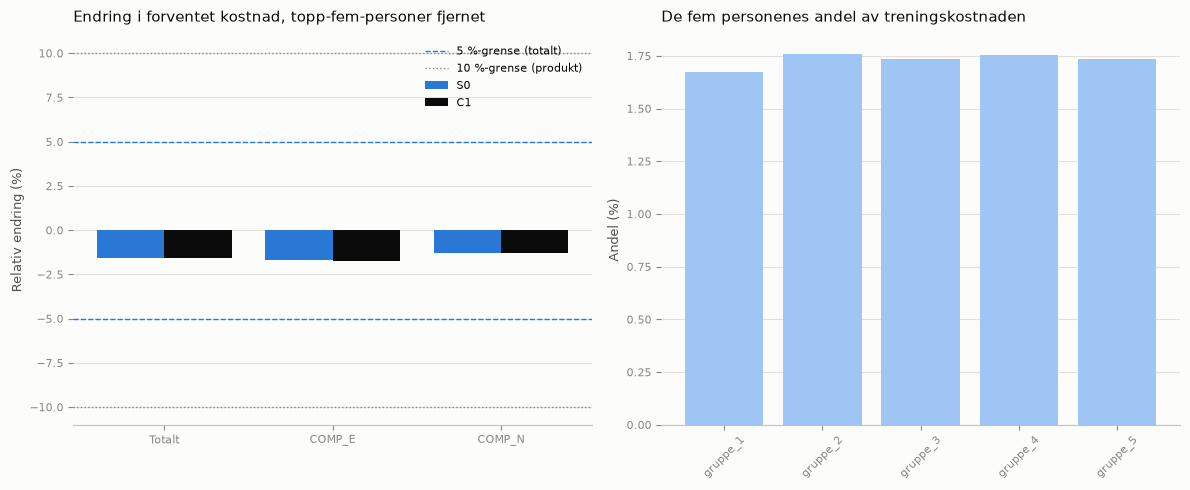

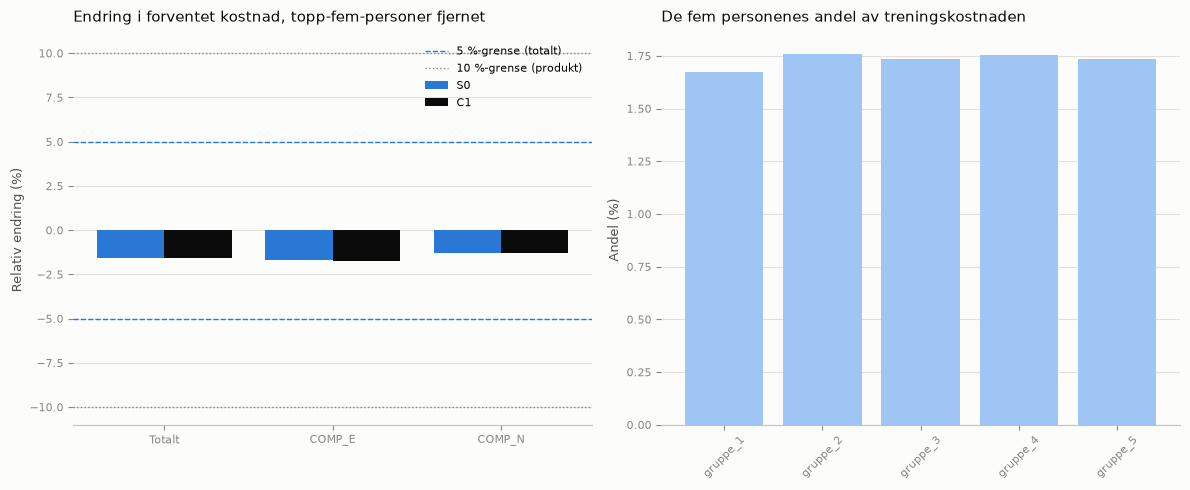

In [42]:
display(severity_influence.plot_influence(influence_table, top_persons))

**Konklusjon 5.4.** Når de fem dyreste personene ble fjernet fra hver
treningsfold, falt C1s poolede forventede kostnad 1,58 %. Produktendringene var
-1,72 % for COMP_E og -1,31 % for COMP_N, klart innenfor grensene 5 % totalt
og 10 % per produkt. Innflytelsesstoppet ble ikke utløst. Dette dokumenterer
bare den låste topp-fem-kontrollen, ikke generell robusthet mot alle
innflytelsesrike observasjoner.

### 5.5 Årskontroll 2022 → 2023

Årskontrollen bruker én fast kalenderovergang. Begge modeller fittes på 2022,
uten årsledd, og evalueres på 2023. Med $Y_i=\bar X_i$ er arbeidsmodellen
$Y_i\sim\operatorname{Gamma}(\mu_i,\phi/N_i)$ og
$\log(\mu_i)=\beta_0+x_i^\top\beta$; `year` er eksplisitt utelatt.

In [43]:
time_control = severity_time.run_year_control(
    severity_specs[FINALIST]["x"],
    severity_specs["S0"]["x"],
    BASE_LEVELS,
    severity_frame,
    FIT_SETTINGS,
    prepare_fold_frames,
    prepare_design_frame,
    finalist_name=FINALIST_LABEL,
)

In [44]:
time_2022 = severity_frame.loc[severity_frame["year"].eq(2022)]
time_2023 = severity_frame.loc[severity_frame["year"].eq(2023)]
time_level_shift = severity_time.build_level_shift_table(
    time_2023, time_control["predictions"], time_2022
)
time_stop = severity_time.evaluate_time_stop(
    time_2023,
    time_control["predictions"],
    reference="S0",
    candidate=FINALIST_LABEL,
)
time_score_table = time_control["scores"].merge(
    time_level_shift[["modell", "A_E", "severity_2022", "severity_2023"]],
    on="modell",
)
time_score_table = time_score_table.assign(
    tidsgevinst_S0_minus_finalist=time_stop["gevinst"],
    SE_cluster=time_stop["SE_cluster"],
    terskel_0_5_prosent=time_stop["terskel_relativ"],
    tidsstopp_utløst=time_stop["utløst"],
)
display(time_score_table.round(6))
print(time_stop["begrunnelse"])

,modell,parametere,pooled_deviance_2023,konvergerte,A_E,severity_2022,severity_2023,tidsgevinst_S0_minus_finalist,SE_cluster,terskel_0_5_prosent,tidsstopp_utløst
0,S0,8,0.708886,True,0.915320,939.77824,846.173811,-0.000645,0.003315,0.003544,False
1,C1,5,0.709531,True,0.916331,939.77824,846.173811,-0.000645,0.003315,0.003544,False


Ingen forverring påvist i denne tidsdelingen.


#### 5.5a Segmentenes A/E

In [45]:
time_segment_ae = severity_time.build_segment_ae_table(
    severity_frame, time_control["predictions_by_year"], total_ae=None
)
display(time_segment_ae.round(4))

,year,variabel,nivå,modell,unike_personer,antall_skadeår,skadeantall,A_E,A_E_total,A_E_relativ
0,2022,policy_type,COMP_E,S0,1216,1216,1652,0.9992,0.9999,0.9992
1,2022,policy_type,COMP_N,S0,506,506,1170,1.0016,0.9999,1.0017
2,2022,skadeantallsgruppe,N=1,S0,1214,1214,1214,1.2883,0.9999,1.2884
3,2022,skadeantallsgruppe,N=2-3,S0,306,306,674,0.8249,0.9999,0.8249
4,2022,skadeantallsgruppe,N>=4,S0,202,202,934,0.6919,0.9999,0.6919
5,2022,policy_type,COMP_E,C1,1216,1216,1652,1.0023,1.0005,1.0017
6,2022,policy_type,COMP_N,C1,506,506,1170,0.9969,1.0005,0.9964
7,2022,skadeantallsgruppe,N=1,C1,1214,1214,1214,1.2866,1.0005,1.2860
8,2022,skadeantallsgruppe,N=2-3,C1,306,306,674,0.8273,1.0005,0.8269
9,2022,skadeantallsgruppe,N>=4,C1,202,202,934,0.6929,1.0005,0.6926


#### 5.5b Segmentdrift

Segmentdriftstopp vurderes separat fra segmentenes A/E-tabell.

In [46]:
time_segment_drift = severity_time.build_segment_drift_table(
    severity_frame,
    time_control["predictions_by_year"],
    min_persons=100,
    n_draws=2000,
    seed=410,
)
assert not time_segment_drift["utløst"].any()
display(time_segment_drift.round(4))

,variabel,nivå,modell,unike_personer_2022,unike_personer_2023,A_E_relativ_2022,A_E_relativ_2023,Q,Q_lav,Q_høy,n_draws,utløst,begrunnelse
0,policy_type,COMP_N,S0,506,1231,1.0017,0.9961,0.9945,0.9063,1.0873,2000,False,Ingen stopp: Q ligger innenfor eller på ±20 %-...
1,policy_type,COMP_E,S0,1216,2745,0.9992,1.0021,1.0029,0.9613,1.0502,2000,False,Ingen stopp: Q ligger innenfor eller på ±20 %-...
2,skadeantallsgruppe,N>=4,S0,202,622,0.6919,0.7399,1.0694,0.9847,1.1670,2000,False,Ingen stopp: Q ligger innenfor eller på ±20 %-...
3,skadeantallsgruppe,N=1,S0,1214,2626,1.2884,1.3326,1.0343,0.9792,1.0930,2000,False,Ingen stopp: Q ligger innenfor eller på ±20 %-...
4,skadeantallsgruppe,N=2-3,S0,306,728,0.8249,0.8418,1.0204,0.9193,1.1329,2000,False,Ingen stopp: Q ligger innenfor eller på ±20 %-...
5,policy_type,COMP_N,C1,506,1231,0.9964,0.9899,0.9935,0.9034,1.0851,2000,False,Ingen stopp: Q ligger innenfor eller på ±20 %-...
6,policy_type,COMP_E,C1,1216,2745,1.0017,1.0055,1.0038,0.9624,1.0522,2000,False,Ingen stopp: Q ligger innenfor eller på ±20 %-...
7,skadeantallsgruppe,N>=4,C1,202,622,0.6926,0.7401,1.0687,0.9834,1.1635,2000,False,Ingen stopp: Q ligger innenfor eller på ±20 %-...
8,skadeantallsgruppe,N=1,C1,1214,2626,1.2860,1.3270,1.0319,0.9764,1.0902,2000,False,Ingen stopp: Q ligger innenfor eller på ±20 %-...
9,skadeantallsgruppe,N=2-3,C1,306,728,0.8269,0.8472,1.0246,0.9213,1.1390,2000,False,Ingen stopp: Q ligger innenfor eller på ±20 %-...


**Konklusjon 5.5b.** For C1 lå normalisert A/E-forhold $Q$ fra 0,9935
(COMP_N; 95 % intervall 0,9034–1,0851) til 1,0687 (`N≥4`;
0,9834–1,1635). Alle produkt- og skadeantallssegmenter hadde minst 202
personer i 2022 og 622 i 2023, alle intervaller inkluderte 1, og ingen endring
oversteg 20 %. Segmentdriftstoppet ble ikke utløst. `N=1` er fortsatt et
selektert skadeårssegment, ikke nødvendigvis én fysisk hendelse.

#### 5.5c Årskostnad

In [47]:
year_cost = severity_time.build_year_cost_table(model_frame, severity_frame)
display(year_cost.round(4))

,year,poliseår,med_registrert_skade,utelatte_nær_null,skadevektet_severity,median_gjennomsnittsskade,samlet_kostnad
0,2022,18992,1726,4,939.7782,655.4310,2652054.192
1,2023,36254,3981,5,846.1738,607.0218,6056065.968


#### 5.5d Miksstandardisering

Miksstandardiseringen er en egen forklarende kontroll; den er ikke en
valideringsscore for et nytt datasett.

Begge årstilpasningene bruker $Y_i\sim\operatorname{Gamma}(\mu_i,\phi/N_i)$
og $\log(\mu_i)=x_i^\top\beta$ uten årsledd. De fittes separat per år og
predikerer samme samlede positive utviklingspopulasjon med samme skadevekter.

In [48]:
mix_standardization = severity_time.run_mix_standardization(
    severity_specs[FINALIST]["x"],
    severity_specs["S0"]["x"],
    BASE_LEVELS,
    severity_frame,
    FIT_SETTINGS,
    prepare_fold_frames,
    prepare_design_frame,
    finalist_name=FINALIST_LABEL,
)
display(mix_standardization["kostnad"].round(6))

,modell,treningsår,forventet_kostnad_på_referansepopulasjon,gjennomsnitt_predikert_severity,forhold_2023_til_2022
0,S0,2022,9.268536e+06,974.138914,0.916806
1,S0,2023,8.491501e+06,893.096084,0.916806
2,C1,2022,9.259678e+06,974.416876,0.917206
3,C1,2023,8.488511e+06,893.740712,0.917206


#### 5.5e Dekning

Dekningstabellen viser hvor mye av referansepopulasjonen som ligger utenfor
treningsårets observerte kovariatområde. Dette er støtteinformasjon, ikke en
ny valideringsscore.

In [49]:
display(mix_standardization["dekning"].round(6))

,treningsår,variabel,andel_utenfor_område
0,2022,circulation_area,0.000000
1,2022,driver_age,0.001229
2,2022,log_vehicle_value,0.000878
3,2022,municipality_type,0.000000
4,2022,policy_type,0.000000
5,2023,circulation_area,0.000000
6,2023,driver_age,0.000000
7,2023,log_vehicle_value,0.000527
8,2023,municipality_type,0.000000
9,2023,policy_type,0.000000


#### 5.5f Årskontroll-plott

Segmenttabellen inneholder begge år. Plottet bruker derfor uttrykkelig bare
2023-delen, siden nivålinjene kommer fra `time_level_shift` for 2023.

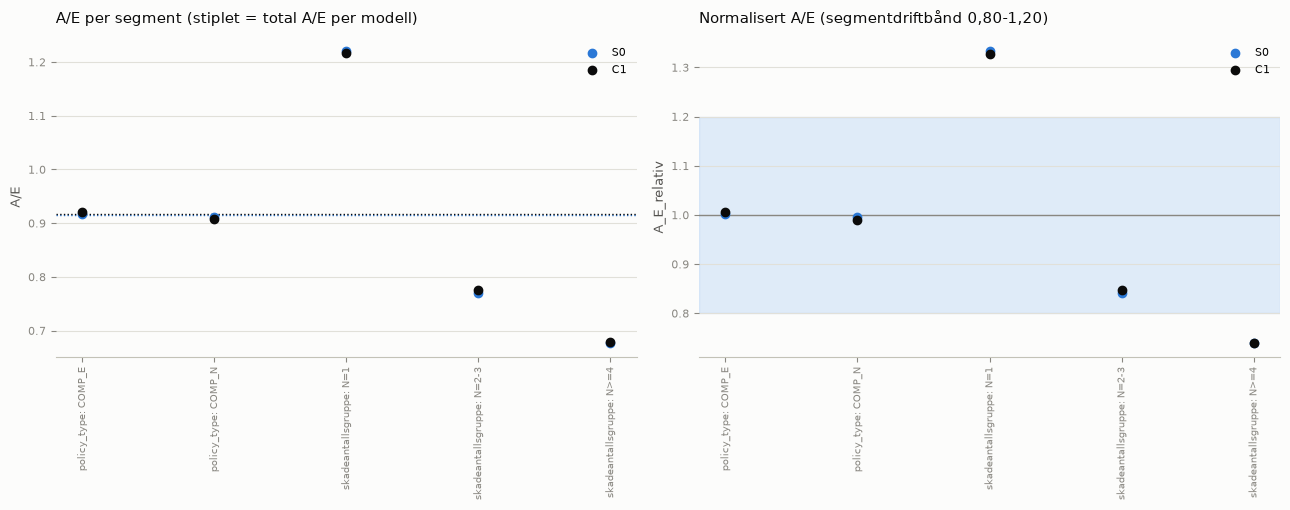

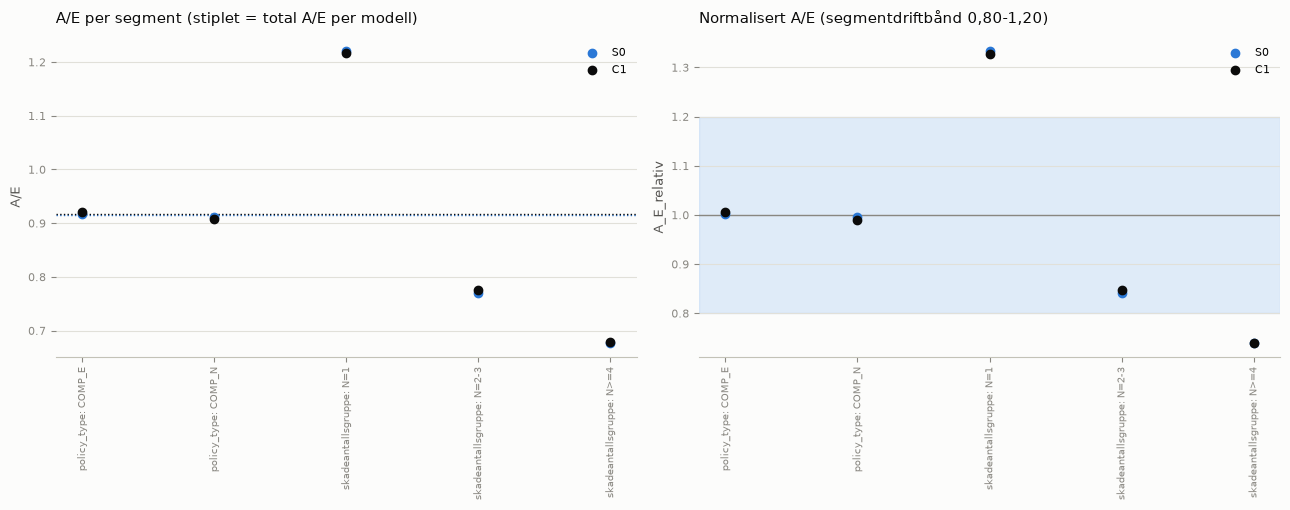

In [50]:
time_segment_ae_2023 = time_segment_ae.loc[time_segment_ae["year"].eq(2023)]
display(severity_time.plot_year_control(time_segment_ae_2023, time_level_shift))

**Konklusjon 5.5.** I 2022→2023-kontrollen var deviance 0,708886 for S0 og
0,709531 for C1. C1s tap 0,000645 var mindre enn både cluster-SE 0,003315 og
0,5 %-grensen 0,003544; ingen forverring ble påvist i denne tidsdelingen.
C1s 2023-A/E var 0,9163, i tråd med det globale fallet i observert severity
fra 939,78 til 846,17 EUR. Miksstandardiseringen ga forhold 0,9172 mellom
2023- og 2022-fitten på samme referansepopulasjon (S0: 0,9168). Høyeste andel
utenfor treningsårets kovariatområde var 0,123 % for alder; kategorisk dekning
var komplett. Verken tids- eller segmentdriftstoppet ble utløst. Én
kalenderovergang dokumenterer likevel ikke generell tidsstabilitet eller
identifisert skadeinflasjon.

### 5.6 Residualdiagnostikk og fortolkningsbegrensning

Deviance-residualene beregnes på 2023-radene som ikke inngikk i 2022-fitten.
Plottet er kun diagnostisk: det kan ikke legitimere ny seleksjon, nye terskler
eller automatisk fjerning av variabler.

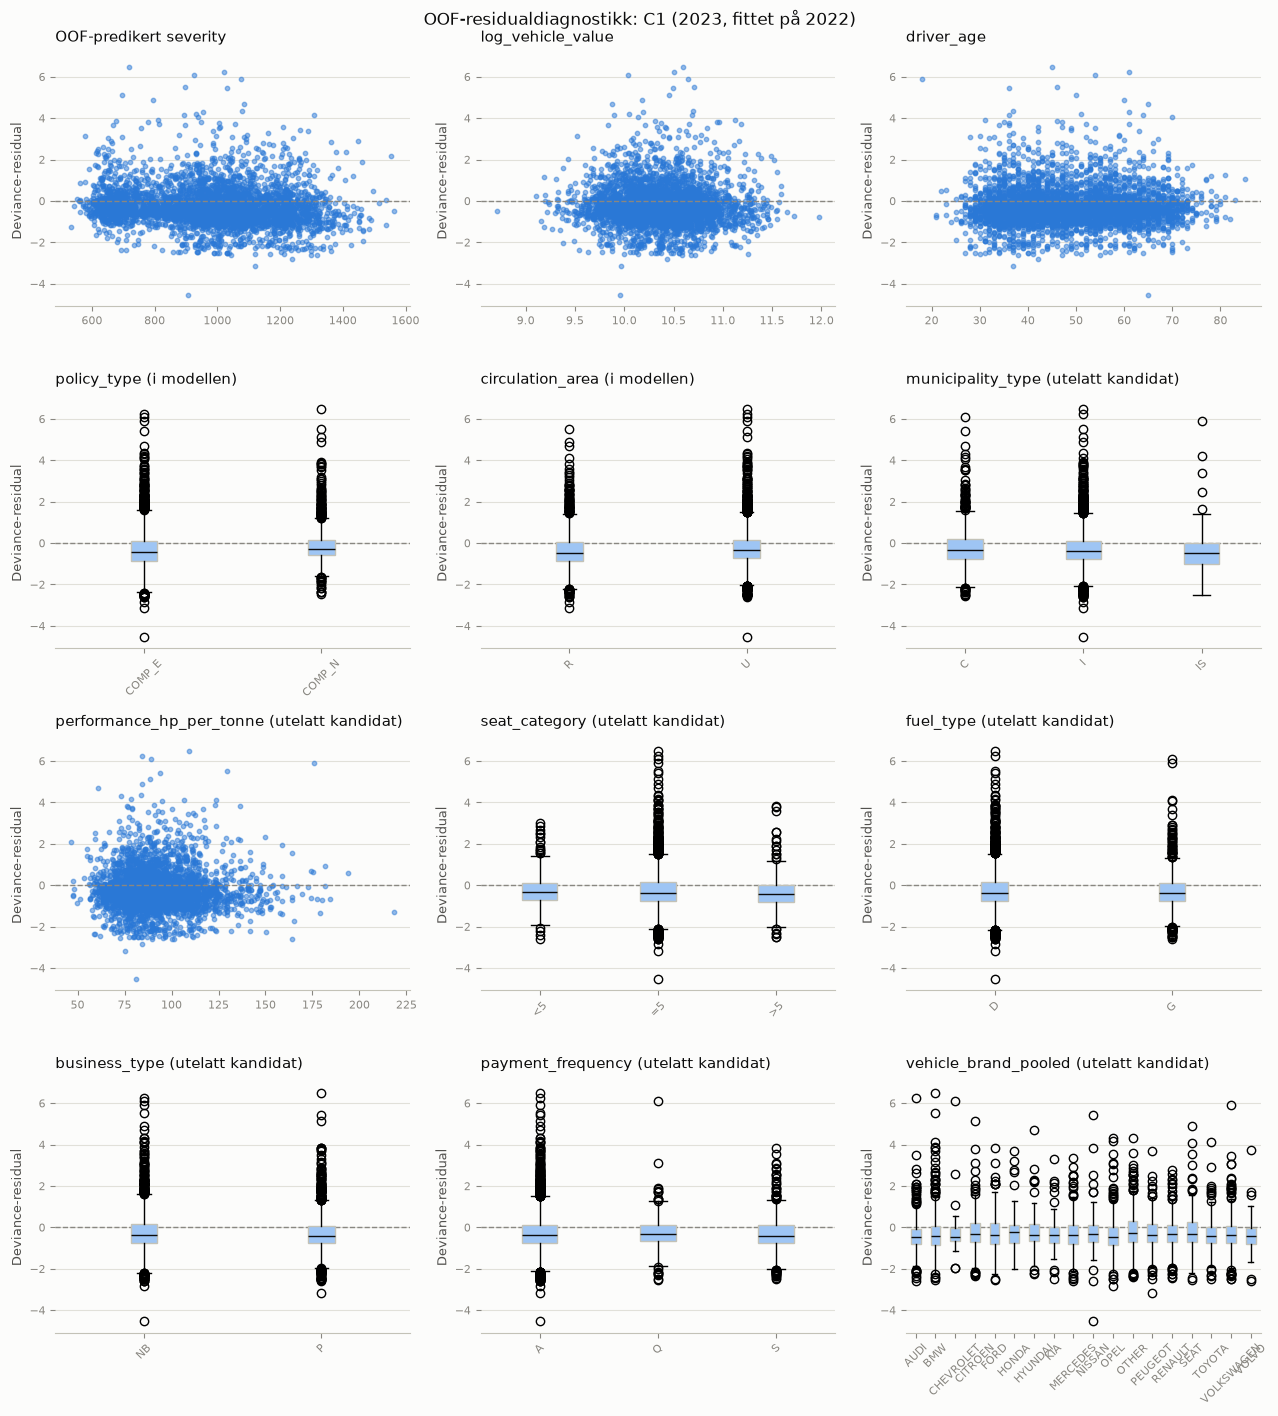

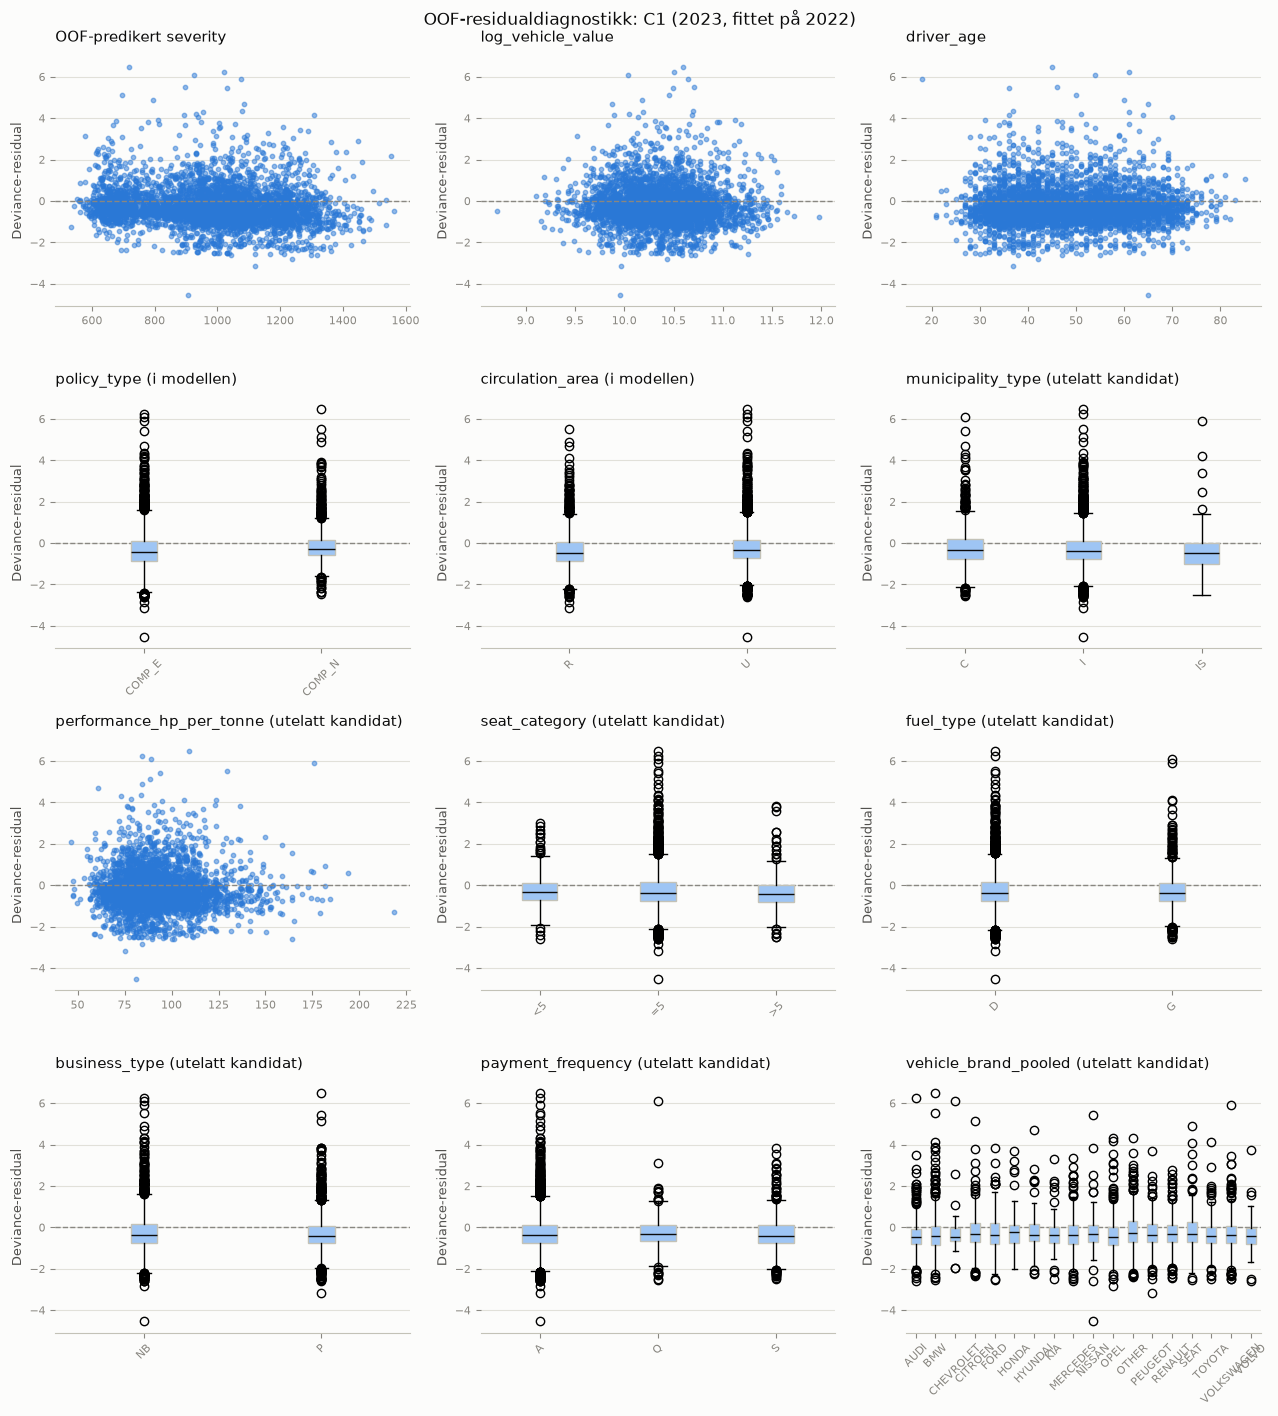

In [51]:
time_finalist_terms = severity_time.drop_year_term(severity_specs[FINALIST]["x"])
display(
    severity_time.plot_oof_residuals(
        FINALIST_LABEL,
        time_finalist_terms,
        time_2023,
        time_control["predictions"],
    )
)

**Konklusjon 5.6.** 2023-residualene var i hovedsak sentrert nær null, men
hadde en tydelig høyre hale med flere store positive avvik og noen store
negative avvik. Det var ingen skarp gjenværende kurvatur mot alder,
log-bilverdi eller predikert severity, men spredningen var ujevn. Produkt og
kjøresone hadde relativt like sentrale fordelinger. Utelatte kategorier viste
enkelte nivåforskjeller og ekstreme observasjoner, særlig blant merker, men
de svakt støttede nivåene kan ikke bære egne konklusjoner. Diagnostikken åpner
derfor ikke et nytt kandidatsøk eller nye terskler.

## 6. Sluttfit og leveranse

Finalisten er C1:

$$
\bar X_i\sim\operatorname{Gamma}(\mu_i,\phi/N_i),
$$

$$
\log(\mu_i)=\beta_0
+\beta_1 I(\mathrm{COMP\_N}_i)
+\beta_2 I(\mathrm{year}_i=2023)
+\beta_3 I(\mathrm{circulation\_area}_i=R)
+\beta_4\log(\mathrm{vehicle\_value}_i)
+\beta_5\mathrm{driver\_age}_i.
$$

Referansene er `COMP_E`, 2022 og urban kjøresone `U`. Modellen sier
intuitivt at forventet registrert kostnad per skade justeres multiplikativt
for produkt, år, kjøresone, bilverdi og en lineær alderseffekt. Sluttfitten
bruker alle 5 698 positive skadeår, skadeantallsvekter og cluster-robuste
standardfeil på `insured_id`; S0 beholdes som dokumentert referanse.

In [52]:
FINAL_SPECS = {
    FINALIST_LABEL: severity_specs[FINALIST],
    "S0": severity_specs["S0"],
}

final_models = {}
for name, spec in FINAL_SPECS.items():
    (design,), _ = prepare_fold_frames(
        spec, severity_frame, [severity_frame], prepare_design_frame
    )
    final_models[name] = fit_glm(
        spec, design, cluster_groups=design["insured_id"], fit_kwargs=FIT_SETTINGS
    )
    assert final_models[name].converged, name

In [53]:
def coefficient_table(model, name):
    """Koeffisienter med cluster-robust SE og multiplikativ relativitet."""
    confidence = model.conf_int()
    return pd.DataFrame({
        "modell": name,
        "ledd": model.params.index,
        "koeffisient": model.params.to_numpy(),
        "SE_cluster": model.bse.to_numpy(),
        "relativitet": np.exp(model.params.to_numpy()),
        "relativitet_lav": np.exp(confidence[0].to_numpy()),
        "relativitet_høy": np.exp(confidence[1].to_numpy()),
    })


final_coefficients = pd.concat(
    [coefficient_table(model, name) for name, model in final_models.items()],
    ignore_index=True,
)
display(final_coefficients.round(4))

,modell,ledd,koeffisient,SE_cluster,relativitet,relativitet_lav,relativitet_høy
0,C1,Intercept,4.9323,0.3799,138.7019,65.8748,292.0421
1,C1,"C(policy_type, Treatment('COMP_E'))[T.COMP_N]",-0.3997,0.0309,0.6705,0.6311,0.7123
2,C1,"C(year, Treatment(2022))[T.2023]",-0.0850,0.0324,0.9186,0.8620,0.9788
3,C1,"C(circulation_area, Treatment('U'))[T.R]",0.1039,0.0338,1.1095,1.0384,1.1855
4,C1,log_vehicle_value,0.1994,0.0368,1.2206,1.1357,1.3119
5,C1,driver_age,-0.0011,0.0012,0.9989,0.9965,1.0013
6,S0,Intercept,4.9863,0.3844,146.3974,68.9146,310.9966
7,S0,"C(policy_type, Treatment('COMP_E'))[T.COMP_N]",-0.4085,0.0304,0.6647,0.6262,0.7055
8,S0,"C(year, Treatment(2022))[T.2023]",-0.0880,0.0328,0.9158,0.8587,0.9766
9,S0,"C(municipality_type, Treatment('I'))[T.C]",0.0282,0.0361,1.0286,0.9584,1.1040


**Tolkning.** Alt annet likt var COMP_N assosiert med 33,0 % lavere severity
enn COMP_E (relativitet 0,6705; 95 % intervall 0,6311–0,7123), og 2023 med
8,1 % lavere nivå enn 2022 (0,9186; 0,8620–0,9788). Rural kjøresone lå
10,9 % over urban (1,1095; 1,0384–1,1855). Koeffisienten 0,1994 på
log-bilverdi betyr omtrent 0,20 % høyere forventet severity ved 1 % høyere
bilverdi. Alderseffekten var -0,11 % per år, men intervallet
0,9965–1,0013 inkluderte ingen effekt. Dette er justerte assosiasjoner, ikke
kausale virkninger, og responsen er registrert `property_incurred`, ikke
dokumentert ultimate skadebeløp.

**Begrensninger.** Reglene foretrekker bevisst enklere modeller, også når de
ikke vinner alle folder. Bare én C1 ble testet; andre delkombinasjoner kan
være bedre uten å være undersøkt. Samme OOF-observasjoner ble brukt gjennom
hele seleksjonskjeden, så utviklingsgevinsten er seleksjonsoptimistisk og har
ingen samlet feilratekontroll. Tidskontrollen dekker bare 2022→2023. FU1 og
BR1 manglet den låste foldstøtten, og små merke-/residualsegmenter er for
svake for egne slutninger. Selv om alder og log-bilverdi hadde liten lineær
korrelasjon, kan andre blokker fortsatt dele forklaringskraft. Responsen er
registrert incurred, ikke ultimate kostnad. Bootstrapen bruker faste
OOF-prediksjoner og inkluderer verken parameter- eller seleksjonsusikkerhet.

## 7. Beslutningsregister

Alle valg som påvirker severity-resultatet, med begrunnelse og hvor de
brukes. Registeret er bindende: et resultat i seksjon 4–6 kan ikke endre en
rad her i ettertid. Frekvensfasens register (B-xx) i
[`glm_pricing_models.ipynb`](glm_pricing_models.ipynb) gjelder fortsatt for
alt severity arver — populasjon, splitt, folder, imputasjon og
splinesentrering.

| ID | Beslutning | Begrunnelse | Status | Seksjon |
|---|---|---|---|---|
| S-01 | Utviklingsdata leses i biter og avgrenses til 2022–2023 **før** rensing (`build_development_frames`). 2024 materialiseres aldri. `build_model_frames` er uendret, så frekvensnotebooken er upåvirket. | Den gamle flyten renset alle år før testrammen ble fjernet. Kontrolltallene viser at omleggingen ikke endret utviklingspopulasjonen. | Brukerbesluttet | 1.1 |
| S-02 | Respons er `property_incurred / property_claims` med `var_weights = property_claims`, uten eksponeringsvekt og uten offset. Utvalget er `property_claims > 0` og `property_incurred > 0,01` (B-15). | Severity er betinget på registrert skade, så eksponeringen er allerede brukt opp av frekvensmodellen. Vekten følger av at snittet av $N$ Gamma-skader har varians $\mu^2/N$. Observasjonene er poliseår, ikke rekonstruerte enkeltskader (åpent punkt B-03). | Brukerbesluttet | 1.2 |
| S-03 | Primærscore er pooled, skadeantallsvektet Gamma-deviance, beregnet med `sklearn.metrics.mean_tweedie_deviance(..., power=2)`. Foldscorene pooles med skadeantall, ikke snittes uvektet. | Etablert bibliotekfunksjon; ingen egen implementasjon å verifisere. Uvektet snitt ville gitt små folder for stor vekt. | Brukerbesluttet | 2.1 |
| S-04 | Usikkerhet måles som parvis cluster-robust SE på score**forskjeller**, gruppert på `insured_id`, med sentrerte clusterbidrag og endelig-antall-korreksjon (`src_severity/severity_scoring.py`). | Parvis sammenligning på de samme radene fjerner foldvariasjonen. Estimatoren er identisk med frekvensfasens Poisson-variant, verifisert numerisk. Den korrigerer ikke for seleksjonsoptimisme. | Brukerbesluttet | 2.2 |
| S-05 | `GroupKFold(n_splits=5, shuffle=True, random_state=100)` på hele modellpopulasjonens `insured_id` (B-06). Severity trenes på foldens positive skadeår. Ingen ny seed, ingen omfordeling, ingen gjentatt CV. | Samme folder som frekvens gjør fasene sammenlignbare og senere koblingsbare. Foldstørrelsene er kontrollert mot planens låste tall. | Brukerbesluttet | 2.3 |
| S-06 | Kandidatrommet er S0 pluss tretten låste utfordrere, inkludert FU1, BU1, PF1 og BR1 som separate blokker. Ingen univariat screening, interaksjoner eller generell baklengs seleksjon. Splines bruker `cr(..., df=k, constraints='center')` (B-10). | Et låst kandidatrom er det som gjør en rapportert utviklingsscore etterprøvbar. Baselinen er faglig og EDA-forankret, men ikke uavhengig av de samme utviklingsårene. | Brukerbesluttet | 2.4 |
| S-07 | Gyldighetskrav i alle fem folder: ≥ 50 unike `insured_id` per kategorinivå i severity-treningen, full rang, endelige parametere, positive endelige prediksjoner, ingen usette nivåer, og konvergens med `maxiter=200`, `tol=1e-8` likt for alle kandidater. | Like innstillinger gjør scoreforskjeller til modellforskjeller, ikke optimeringsforskjeller. Ingen redningsforsøk med ny pooling eller regularisering. | Brukerbesluttet | 2.5 |
| S-08 | Forbedring: $D_{\text{ref}} - D_{\text{kand}} > \max(\mathrm{SE}_{\text{par}}, 0{,}005\,D_{\text{ref}})$ og ≥ 4/5 folder. Forenkling: $D_{\text{kand}} - D_{\text{ref}} \le \min(\mathrm{SE}_{\text{par}}, 0{,}005\,D_{\text{ref}})$, uten foldkrav. Reglene er testet syntetisk i `src_severity/selection_tests.py`. | Asymmetrien uttrykker den avtalte preferansen for enkelhet. Grensene er konservative beslutningsheuristikker, ikke signifikanstester, og gir ingen kontrollert samlet feilrate. | Brukerbesluttet | 2.6 |
| S-09 | Algoritmen kjøres **én** gang i den låste rekkefølgen, med geografisærregelen for G2 og høyst én kombinert kandidat C1. Protokollmaksimum: 14 faste spesifikasjoner × 5 folder = 70 hovedtilpasninger; 75 med C1. Før-fit-ugyldige kandidater fittes ikke. Diagnostiske refittinger føres separat og kan ikke bli kandidater. | Én gjennomkjøring uten omkamp er det som holder seleksjonsoptimismen på et nivå vi kan beskrive. Søket er avsluttet også når konklusjonen blir at S0 beholdes. | Brukerbesluttet | 2.7 |
| S-10 | Designmatrisene bygges og kontrolleres foldvis mot kandidatregisteret før første kandidatfit. Avvik håndteres etter S-07 — parametertall eller nivåer endres aldri stille for å få en kandidat til å passe. | Registerets nivåer, referanser og parametertall er kontrollert mot de faktiske foldvise designmatrisene før seleksjonen. | Implementert/verifisert | 3.5 |
| S-11 | OOF-prediksjoner lagres for **alle** poliseår i valideringsfolden, ikke bare de positive skadeårene, via et `fold_hook`. Severity-scoren beregnes fortsatt kun på det definerte positive utvalget. | Alle utviklingsrader fikk én OOF-prediksjon, slik at senere frekvens–severity-sammenkobling kan bruke komplette prediksjoner. | Implementert/verifisert | 2.3 |
| S-12 | FU1 og BR1 forkastes før fit. BU1 og PF1 går videre til CV. | FU1s `MISSING`-nivå hadde 39–43 personer; BR1s `CHEVROLET`-nivå 42–50 og var under kravet i fire folder. Ingen redningspooling. | Resultat/verifisert | 3.4 |
| S-13 | A1, A2 og G1 kvalifiserer; blokkvalget endrer alder til A1 og geografi til G1. | Forenklings- og nesten-like-reglene ble anvendt én gang. BU1 og PF1 kvalifiserte ikke. | Resultat/verifisert | 4.2–4.4 |
| S-14 | C1 med lineær alder og kjøresone velges som finalist; 65 hovedfits ble brukt. | C1 hadde seks parametere, deviance 0,724835 og kvalifiserte mot S0, A1 og G1. C1 var alene nesten lik beste score. | Resultat/verifisert | 4.5–4.7 |
| S-15 | Kalibrerings-, bootstrap- og småbeløpskontrollene utløser ikke stopp. | Total C1 A/E 1,0003 (95 % intervall 0,9689–1,0326); gevinst mot S0 0,004170 (0,000126–0,008603); ≤1 EUR bidro med 0,28 % av deviancen. | Resultat/verifisert | 5.1–5.3 |
| S-16 | Topp-fem-personer-kontrollen utløser ikke innflytelsesstopp. | C1s forventede kostnad endret seg -1,58 % totalt og maksimalt -1,72 % per produkt. | Resultat/verifisert | 5.4 |
| S-17 | Tids- og segmentdriftstoppene utløses ikke. | C1 tapte 0,000645 mot S0 i 2023, mindre enn SE 0,003315 og 0,5 %-grensen 0,003544. Alle støttede Q-intervaller inkluderte 1. Dette er ingen dokumentasjon på generell tidsstabilitet. | Resultat/verifisert | 5.5 |
| S-18 | C1 refittes på alle 5 698 positive skadeår med cluster-robuste standardfeil; S0 beholdes som referanse. | Alle sluttfits konvergerte med låst preprocessing og Gamma/log-spesifikasjon. | Implementert/verifisert | 6 |